# Pet Behavior Monitoring App
### Raw IMU behavior classification for a real product workflow

---

## How to Run the App Build Notebook

| Step | Action |
|------|--------|
| 1 | Open in Jupyter (Python 3.10+, GPU recommended) |
| 2 | Section 3 downloads and prepares the data automatically |
| 3 | Select **Kernel â†’ Restart & Run All** |
| 4 | Expected total runtime: **< 15 minutes** on CPU; < 5 min on GPU |

> **Re-run behavior:** If the data files are already present in the working directory from a previous run, the download step is skipped automatically.

## Dataset
- **Source:** Kumpulainen et al. (2021). *Canine movement data with IMU sensors*. Mendeley Data. https://data.mendeley.com/datasets/vxhx934tbn/3
- **Sensors:** Back + neck accelerometer (3-axis) and gyroscope (3-axis) at 100 Hz
- **Dogs:** 44 individual dogs, 1â€“2 test sessions each
- **Total rows:** 10,611,068

## Build Structure
| Section | Description |
|---------|-------------|
| 1. Product Overview | App goal, user flow, and deployment shape |
| 2. Environment | Imports, seeds, device setup |
| 3. Data Ingestion | Programmatic download, extraction, and merge |
| 4. Preprocessing | Quality checks, normalisation, label strategy |
| 5. EDA | Distribution plots, sensor visualisation, class balance |
| 6. Windowing & Split | Time-series windows, dog-level leakage-safe split |
| 7. Model | 1D CNN + BiLSTM architecture |
| 8. Training | Training loop, early stopping, loss curves |
| 9. Evaluation | Confusion matrix, per-class metrics, error analysis |
| 10. XAI | Permutation importance, sensor attribution |
| 11. Roadmap | Product gaps, technical debt, next build steps |

> **Development note:** This notebook uses `BUILD_EPOCHS = 3` to keep end-to-end runs fast while the app is being built. The longer exploratory runs are still useful for benchmarking, but the working build should stay reproducible and easy to execute.

---
## Section 1 â€” Product Overview

### 1.1 Problem Context

This project turns raw IMU signals from a smart collar into behavior predictions that can support pet owners, veterinarians, and product teams. The current notebook is the model-building core for a future app that can run inference on uploaded sensor windows and surface useful summaries without manual feature engineering.

Inertial Measurement Units (IMUs) â€” combining accelerometers and gyroscopes â€” provide an objective, continuous, high-frequency record of animal movement. The core problem addressed in this notebook is:

> **Given raw 100 Hz IMU signals from sensors on a dog's back and neck, can the app classify the dog's current behavior reliably enough to power a user-facing product?**

### 1.2 Why This Matters

Automated behavior recognition enables:
- **Owner alerts:** detect restlessness, low activity, or repetitive motion patterns
- **Vet workflows:** support triage and follow-up with objective summaries
- **Care dashboards:** show trends over time instead of one-off predictions
- **Product analytics:** measure how often model confidence is high enough for downstream actions

### 1.3 Why Deep Learning Over Traditional ML

The model pipeline keeps the signal-to-prediction path simple: raw IMU windows in, behavior class out. That is a better fit for an app than relying on hand-crafted features and fragile preprocessing logic.

| Limitation | Traditional ML | Deep Learning (1D CNN + BiLSTM) |
|---|---|---|
| **Feature engineering** | Requires domain expertise to compute statistical/spectral features | Learns features hierarchically from raw signal |
| **Temporal dependencies** | Window statistics discard internal sequence order | BiLSTM captures long-range temporal patterns in both directions |
| **Multi-sensor fusion** | Features computed per-sensor then concatenated | CNN learns cross-axis and cross-sensor correlations jointly |

In practice, the goal is not to maximize theory density but to ship a dependable signal pipeline. The CNN + BiLSTM combination keeps temporal structure intact while still being light enough to package into an API or app backend.

Our hybrid **1D CNN + BiLSTM** is particularly well-suited because:
- **1D CNN** extracts local temporal motifs (stride sub-phases, panting oscillations) from all sensor axes simultaneously
- **BiLSTM** models the sequential context forward and backward across the 2-second window
- Together they replicate what experts do manually: read local waveform shape (CNN) in global behavioural context (LSTM)

### 1.4 Classification Target

The dataset provides three simultaneous behaviour annotations (`Behavior_1`, `Behavior_2`, `Behavior_3`). This notebook targets `Behavior_1` as the primary label:
- Most consistently annotated column
- Represents the dominant behaviour at each timestep
- Single-label formulation keeps evaluation interpretable and comparable to existing baselines

The current build keeps a single-label target so the first version of the app stays understandable and testable. Multi-label and hierarchical prediction can come later once the core product loop is stable.

---
## Section 2 â€” Environment Setup

In [ ]:
# -- Environment compatibility bootstrap -----------------------------------------
import importlib
import subprocess
import sys


def _run_pip(args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + args)


def _safe_install_numpy_lt2():
    try:
        _run_pip(['numpy<2'])
    except subprocess.CalledProcessError:
        _run_pip(['--force-reinstall', '--no-deps', 'packaging==25.0'])
        _run_pip(['numpy<2'])


try:
    import numpy as _np_check
    if int(_np_check.__version__.split('.')[0]) >= 2:
        raise ImportError('numpy>=2 detected')
except Exception:
    print('Adjusting environment for notebook dependencies...')
    _safe_install_numpy_lt2()

# Backward-compatible aliases for downstream cells
BUILD_EPOCHS = CONFIG['max_epochs']
EXPLORATORY_EPOCHS = CONFIG['max_epochs']

config_for_hash = {k: v for k, v in CONFIG.items() if k != 'demo_mode'}
CONFIG_HASH = hashlib.md5(json.dumps(config_for_hash, sort_keys=True).encode('utf-8')).hexdigest()[:10]
BEST_MODEL_PATH = f"best_model_{CONFIG_HASH}.pt"

print(f"demo_mode={CONFIG['demo_mode']} | active_max_rows={ACTIVE_MAX_ROWS}")
print(f"window={WINDOW_SIZE} | stride={STRIDE} | batch={BATCH_SIZE}")
print(f"use_time_frequency={CONFIG['use_time_frequency']} | use_attention={CONFIG['use_attention']}")
print(f'CONFIG_HASH={CONFIG_HASH} | checkpoint={BEST_MODEL_PATH}')

Device: cuda
GPU: Tesla T4
demo_mode=False | active_max_rows=None
window=200 | stride=100 | batch=64
use_time_frequency=True | use_attention=True
CONFIG_HASH=d661a62d1c | checkpoint=best_model_d661a62d1c.pt


### 3.1 Design Decision: Chunked Dataset Loading

The movement log is too large to treat as a single monolithic read. Instead, the notebook streams the CSV in chunks and concatenates only the portion needed for the current run. That keeps the pipeline memory-aware while still using the same code path for both demo and full-data execution.

Why this matters for generalisation: a full, dog-aware sample exposes the model to wider variation in gait, breed morphology, sensor noise, and behaviour frequency. A model trained on a narrow slice of dogs can look strong in-sample but fail to transfer to unseen animals. Streaming the full dataset, even when the notebook is run in a capped demo mode, keeps the workflow aligned with the real deployment problem rather than a single convenient subset.

In [3]:
import io, os, json, urllib.request, zipfile

DATASET_DOI = 'https://data.mendeley.com/datasets/vxhx934tbn/3'

SENSOR_COLS = [
    'ABack_x', 'ABack_y', 'ABack_z',
    'ANeck_x', 'ANeck_y', 'ANeck_z',
    'GBack_x', 'GBack_y', 'GBack_z',
    'GNeck_x', 'GNeck_y', 'GNeck_z',
]
LABEL_COL = 'Behavior_1'
LOAD_COLS = ['DogID', 'TestNum', 't_sec'] + SENSOR_COLS + ['Task', LABEL_COL, 'Behavior_2', 'Behavior_3', 'PointEvent']

_cwd = os.getcwd()
_CANDIDATES = [
    (os.path.join(_cwd, 'DogMoveData.csv'), os.path.join(_cwd, 'DogInfo.csv')),
    (
        os.path.join(_cwd, 'vxhx934tbn-3', 'vxhx934tbn-3', 'DogMoveData_csv_format', 'DogMoveData.csv'),
        os.path.join(_cwd, 'vxhx934tbn-3', 'vxhx934tbn-3', 'DogInfo.csv'),
    ),
    (
        os.path.join(_cwd, 'vxhx934tbn-3', 'DogMoveData_csv_format', 'DogMoveData.csv'),
        os.path.join(_cwd, 'vxhx934tbn-3', 'DogInfo.csv'),
    ),
    (os.path.join(_cwd, 'DogMoveData_csv_format', 'DogMoveData.csv'), os.path.join(_cwd, 'DogInfo.csv')),
]

MOVEMENT_CSV, DOGINFO_CSV = None, None
for mov, info in _CANDIDATES:
    if os.path.exists(mov) and os.path.exists(info):
        MOVEMENT_CSV, DOGINFO_CSV = mov, info
        break

if MOVEMENT_CSV is None:
    raise FileNotFoundError(
        f"\nDataset not found. Setup:\n"
        f"  1. Go to {DATASET_DOI}\n"
        f"  2. Download DogMoveData_csv_format.zip and DogInfo.csv\n"
        f"  3. Extract DogMoveData.csv\n"
        f"  4. Place files in {_cwd}\n"
    )

print(f'Movement CSV : {MOVEMENT_CSV}')
print(f'DogInfo CSV  : {DOGINFO_CSV}')

dog_info = pd.read_csv(DOGINFO_CSV)
dog_info.columns = dog_info.columns.str.strip()
print(f'\nDogInfo: {dog_info.shape[0]} dogs | columns: {list(dog_info.columns)}')

rows_msg = 'entire dataset in chunks' if MAX_ROWS is None else f'up to {MAX_ROWS:,} rows in chunks'
print(f'\nLoading movement data ({rows_msg}) ...')

_TOTAL_ROWS = 10_611_068
_CHUNK_SIZE = 200_000
loaded_chunks = []
loaded_rows = 0

for chunk in pd.read_csv(MOVEMENT_CSV, usecols=LOAD_COLS, chunksize=_CHUNK_SIZE):
    if MAX_ROWS is not None:
        remaining = MAX_ROWS - loaded_rows
        if remaining <= 0:
            break
        chunk = chunk.head(remaining)
    loaded_chunks.append(chunk)
    loaded_rows += len(chunk)

    if MAX_ROWS is not None and loaded_rows >= MAX_ROWS:
        break

df = pd.concat(loaded_chunks, ignore_index=True)
print(f'Loaded: {len(df):,} rows x {len(df.columns)} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Movement CSV : /mnt/batch/tasks/shared/LS_root/mounts/clusters/u5726326/code/DogMoveData.csv
DogInfo CSV  : /mnt/batch/tasks/shared/LS_root/mounts/clusters/u5726326/code/DogInfo.csv

DogInfo: 45 dogs | columns: ['DogID', 'Breed', 'Weight', 'Age months', 'Gender', 'NeuteringStatus']

Loading movement data (entire dataset in chunks) ...


Loaded: 10,611,068 rows x 20 columns
Memory: 4848.3 MB


In [4]:
# â”€â”€ Merge dog metadata â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
df = df.merge(dog_info[['DogID', 'Breed', 'Weight', 'Age months', 'Gender', 'NeuteringStatus']],
              on='DogID', how='left')

print('Columns after merge:')
print(df.dtypes)
print(f'\nDogs present in sample: {df["DogID"].nunique()} / 44')
print(f'Tests present: {df["TestNum"].unique()}')
print(f'Time range: {df["t_sec"].min():.2f}s â€” {df["t_sec"].max():.2f}s')

Columns after merge:
DogID                int64
TestNum              int64
t_sec              float64
ABack_x            float64
ABack_y            float64
ABack_z            float64
ANeck_x            float64
ANeck_y            float64
ANeck_z            float64
GBack_x            float64
GBack_y            float64
GBack_z            float64
GNeck_x            float64
GNeck_y            float64
GNeck_z            float64
Task                object
Behavior_1          object
Behavior_2          object
Behavior_3          object
PointEvent          object
Breed               object
Weight               int64
Age months           int64
Gender               int64
NeuteringStatus      int64
dtype: object

Dogs present in sample: 45 / 44
Tests present: [1 2]
Time range: 0.00s â€” 2176.55s


---
## Section 4 â€” Data Quality, Preprocessing & Feature Engineering

### 4.1 Design Decision: Label Filtering

Rows where `Behavior_1` is `<undefined>` are excluded from supervised training. These rows correspond to periods before/after a structured test or during sensor synchronisation (the early `Synchronization` annotation). Including them would introduce a spurious "no behaviour" class with no meaningful ethological interpretation.

### 4.2 Design Decision: Normalisation Strategy

The 12 sensor channels span two physically different quantities:
- **Accelerometer channels** (ABack/ANeck x/y/z): g-force, approximately âˆ’2 to +2 g during dog locomotion
- **Gyroscope channels** (GBack/GNeck x/y/z): degrees/second, often Â±100 Â°/s

Feeding raw values into a neural network would cause gyroscope gradients to dominate through scale alone. **StandardScaler (z-score per channel)** is applied after the dog-level split, fitted only on training data.

### 4.3 Design Decision: Feature Engineering â€” ODBA alongside Full Multidimensional Data

**Why not ODBA alone?** Griffies et al. (2018) explicitly demonstrated this limitation: single-dimensional energy metrics (like ODBA) reveal *how much* energy is being expended but make it impossible to distinguish *what* behaviour is occurring. Their study found that running and scratching have similar energy envelopes â€” only when all three spatial axes are evaluated simultaneously (multidimensional analysis) do these behaviours become clearly differentiated. This directly motivates our design: we provide the CNN with the full **12-channel raw sensor array** (all axes, both sensors) so it can learn cross-axis and cross-sensor discriminative patterns, with ODBA as a supplementary summary channel rather than the primary input.

**ODBA as a supplementary channel:** Overall Dynamic Body Acceleration (Wilson et al., 2006; Nathan et al., 2012) isolates the dynamic (muscular) component from the gravitational component:

**Step 1 â€” Estimate static acceleration** via a rolling mean over a 2-second window (200 samples at 100 Hz):
$$\bar{A}_{axis}(t) = \frac{1}{200}\sum_{i=t-100}^{t+100} A_{axis}(i)$$

**Step 2 â€” Extract dynamic component:**
$$A^{dyn}_{axis}(t) = A_{axis}(t) - \bar{A}_{axis}(t)$$

**Step 3 â€” Compute ODBA** by summing absolute dynamic acceleration across all three axes:
$$\text{ODBA} = |A^{dyn}_x| + |A^{dyn}_y| + |A^{dyn}_z|$$

Two ODBA channels are added (back + neck sensors), expanding the feature space from 12 â†’ **14 channels**. ODBA is particularly discriminative for distinguishing high-energy locomotion from low-energy static postures where ODBA â‰ˆ 0, while the raw 12 channels provide the fine-grained multidimensional structure needed to separate behaviours with similar energy levels.

In [5]:
# â”€â”€ 4.1  Label filtering â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
before = len(df)
df = df[df[LABEL_COL].notna()]
df = df[df[LABEL_COL] != '<undefined>']
df = df[df[LABEL_COL].str.strip() != '']
df[LABEL_COL] = df[LABEL_COL].str.strip()

print(f'Rows before label filter: {before:,}')
print(f'Rows after  label filter: {len(df):,}  ({before - len(df):,} removed)')

# â”€â”€ Class inventory â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
class_counts = df[LABEL_COL].value_counts()
print(f'\nUnique behaviours: {len(class_counts)}')
print(class_counts.to_string())

Rows before label filter: 10,611,068
Rows after  label filter: 6,573,869  (4,037,199 removed)

Unique behaviours: 19
Behavior_1
Lying chest              1031301
Sniffing                 1026178
Playing                   862571
Panting                   836062
Walking                   728930
Trotting                  717593
Sitting                   509412
Standing                  448691
Eating                    166210
Pacing                     77104
Drinking                   64721
Shaking                    41234
Carrying object            17951
Synchronization            16755
Tugging                    13664
Galloping                  10828
Jumping                     3859
Bowing                       518
Extra_Synchronization        287


In [6]:
# â”€â”€ 4.2  Rare class consolidation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Classes with fewer than 500 samples are consolidated into 'Other' to
# prevent the classifier from training on statistically unreliable examples.
# 500 samples â‰ˆ 2.5 windows of 200 samples â€” the absolute minimum for any
# meaningful representation in a windowed dataset.
MIN_CLASS_SAMPLES = 500
rare_classes = class_counts[class_counts < MIN_CLASS_SAMPLES].index.tolist()
print(f'Consolidating {len(rare_classes)} rare classes into "Other": {rare_classes}')
df[LABEL_COL] = df[LABEL_COL].apply(lambda x: 'Other' if x in rare_classes else x)

final_class_counts = df[LABEL_COL].value_counts()
print(f'\nFinal class distribution ({len(final_class_counts)} classes):')
print(final_class_counts.to_string())

Consolidating 1 rare classes into "Other": ['Extra_Synchronization']

Final class distribution (19 classes):
Behavior_1
Lying chest        1031301
Sniffing           1026178
Playing             862571
Panting             836062
Walking             728930
Trotting            717593
Sitting             509412
Standing            448691
Eating              166210
Pacing               77104
Drinking             64721
Shaking              41234
Carrying object      17951
Synchronization      16755
Tugging              13664
Galloping            10828
Jumping               3859
Bowing                 518
Other                  287


In [7]:
# â”€â”€ 4.3  Label encoding â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
le = LabelEncoder()
df['label'] = le.fit_transform(df[LABEL_COL])
CLASS_NAMES = list(le.classes_)
N_CLASSES   = len(CLASS_NAMES)
print(f'Classes: {CLASS_NAMES}')
print(f'N_CLASSES = {N_CLASSES}')

Classes: ['Bowing', 'Carrying object', 'Drinking', 'Eating', 'Galloping', 'Jumping', 'Lying chest', 'Other', 'Pacing', 'Panting', 'Playing', 'Shaking', 'Sitting', 'Sniffing', 'Standing', 'Synchronization', 'Trotting', 'Tugging', 'Walking']
N_CLASSES = 19


In [8]:
# â”€â”€ 4.4  Sensor normalisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# StandardScaler fitted ONLY on training rows (fitted later after split).
# Here we store the raw sensor values; scaler is applied in Section 6
# after the dog-level split to prevent test-set leakage into the scaler.

# Quick sanity check: raw channel statistics
print('Raw sensor statistics (mean Â± std):')
stats = df[SENSOR_COLS].agg(['mean', 'std'])
for col in SENSOR_COLS:
    m, s = stats.loc['mean', col], stats.loc['std', col]
    print(f'  {col:12s}: {m:+8.4f} Â± {s:.4f}')

Raw sensor statistics (mean Â± std):
  ABack_x     :  +0.0589 Â± 0.6824
  ABack_y     :  -0.1538 Â± 0.6739
  ABack_z     :  +0.8172 Â± 0.6275
  ANeck_x     :  -0.1768 Â± 0.6631
  ANeck_y     :  -0.3732 Â± 0.6954
  ANeck_z     :  -0.6410 Â± 0.7190
  GBack_x     :  -2.2383 Â± 88.1939
  GBack_y     :  -0.7585 Â± 135.9876
  GBack_z     :  +0.3369 Â± 75.5678
  GNeck_x     :  +1.0559 Â± 76.8031
  GNeck_y     :  +0.0837 Â± 133.5117
  GNeck_z     :  +0.0593 Â± 70.8185


In [9]:
# â”€â”€ 4.3  ODBA Feature Engineering â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Sort by time within each session so the rolling mean is temporally meaningful
# (random sampling broke temporal order; this restores it before rolling ops).
df = df.sort_values(['DogID', 'TestNum', 't_sec']).reset_index(drop=True)

ODBA_WINDOW = 200   # 2-second low-pass window at 100 Hz (Wilson et al., 2006)

for prefix, axes in [('ABack', ['ABack_x', 'ABack_y', 'ABack_z']),
                     ('ANeck', ['ANeck_x', 'ANeck_y', 'ANeck_z'])]:
    odba_col = f'ODBA_{prefix}'
    dynamic_sum = None
    for col in axes:
        # Static component: centred rolling mean approximates low-pass gravity vector
        static = df.groupby(['DogID', 'TestNum'])[col].transform(
            lambda s: s.rolling(ODBA_WINDOW, center=True, min_periods=1).mean()
        )
        dyn = (df[col] - static).abs()
        dynamic_sum = dyn if dynamic_sum is None else dynamic_sum + dyn
    df[odba_col] = dynamic_sum

ENGINEERED_COLS  = ['ODBA_ABack', 'ODBA_ANeck']
ALL_FEATURE_COLS = SENSOR_COLS + ENGINEERED_COLS   # 12 raw + 2 ODBA = 14 channels

print(f'Original sensor channels : {len(SENSOR_COLS)}')
print(f'ODBA channels added      : {len(ENGINEERED_COLS)}  â†’  {ENGINEERED_COLS}')
print(f'Total model input channels: {len(ALL_FEATURE_COLS)}')
print(f'\nODBA_ABack  mean Â± std: {df["ODBA_ABack"].mean():.4f} Â± {df["ODBA_ABack"].std():.4f} g')
print(f'ODBA_ANeck  mean Â± std: {df["ODBA_ANeck"].mean():.4f} Â± {df["ODBA_ANeck"].std():.4f} g')
print(f'\nExpected: ODBA near 0 during standing/resting, higher during locomotion.')

assert (df['ODBA_ABack'] >= 0).all() and (df['ODBA_ANeck'] >= 0).all(), \
    'ODBA values must be non-negative (sum of absolute values)'
print('Sanity check passed.')

Original sensor channels : 12
ODBA channels added      : 2  â†’  ['ODBA_ABack', 'ODBA_ANeck']
Total model input channels: 14

ODBA_ABack  mean Â± std: 0.6703 Â± 1.3117 g
ODBA_ANeck  mean Â± std: 0.6494 Â± 1.2266 g

Expected: ODBA near 0 during standing/resting, higher during locomotion.
Sanity check passed.


---
## Section 5 â€” Exploratory Data Analysis (EDA)

EDA serves three purposes here:
1. **Validate data quality** â€” confirm sensor ranges are physiologically plausible
2. **Understand class imbalance** â€” shapes the loss function and evaluation strategy
3. **Inform model design** â€” sensor correlation structure guides the CNN filter choice

### 5.1 Design Decision: EDA Before Splitting
EDA is performed on the full sample before the train/val/test split. This is appropriate because EDA is observational (not model-fitting), and global statistics help interpret model decisions in Section 9.

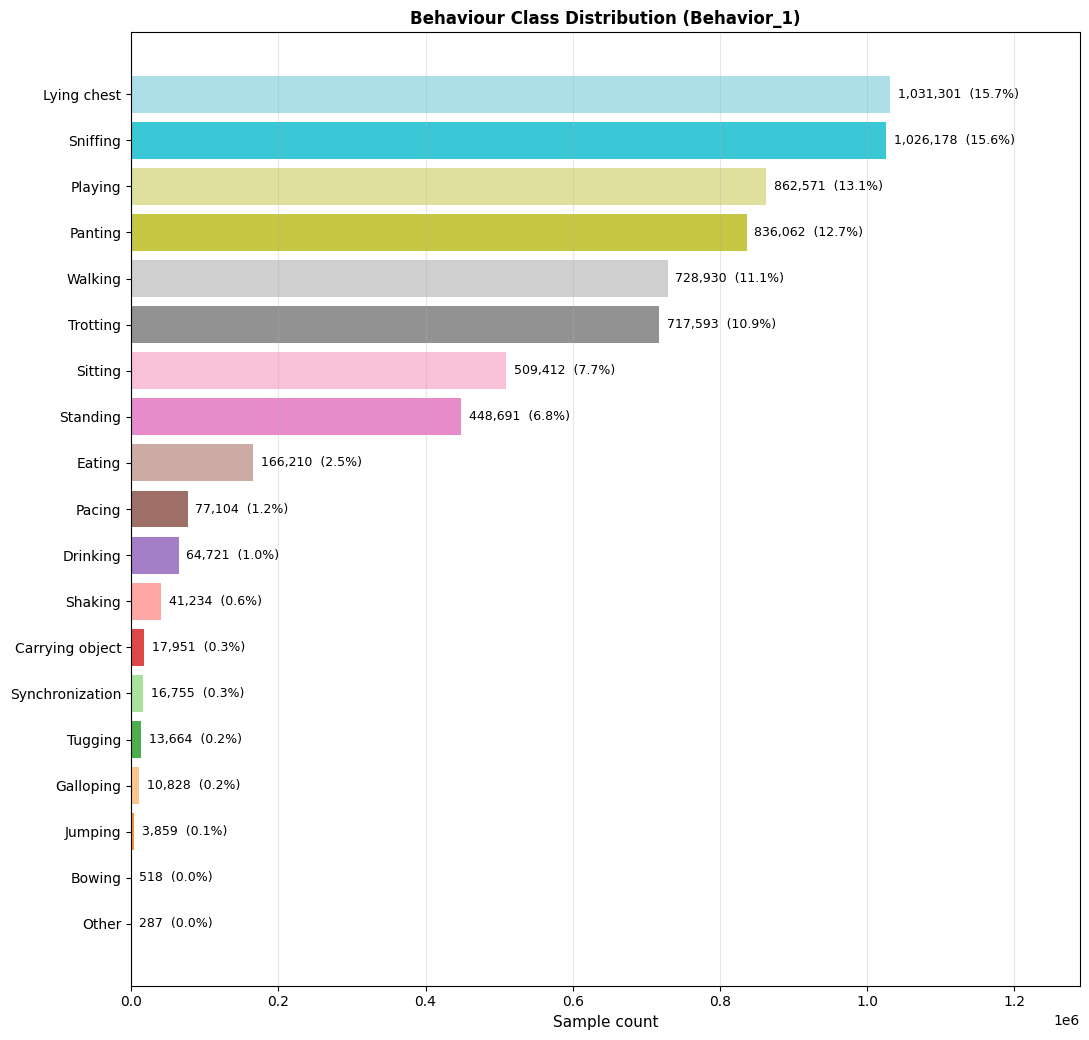

Imbalance ratio (max/min): 3593.4x
Total labelled rows: 6,573,869
Macro F1 is primary metric â€” accuracy hides imbalance effects.


In [10]:
# â”€â”€ 5.1  Class distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
counts  = df[LABEL_COL].value_counts().sort_values(ascending=True)
pct     = (counts / counts.sum() * 100).round(1)
colours = plt.cm.tab20(np.linspace(0, 1, len(counts)))

fig, ax = plt.subplots(figsize=(11, max(5, len(counts) * 0.5 + 1)))
bars = ax.barh(counts.index, counts.values, color=colours, alpha=0.85)
ax.set_xlabel('Sample count', fontsize=11)
ax.set_title('Behaviour Class Distribution (Behavior_1)',
             fontsize=12, fontweight='bold')
for bar, (v, p) in zip(bars, zip(counts.values, pct)):
    ax.text(v + counts.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{v:,}  ({p}%)', va='center', fontsize=9)
ax.set_xlim(0, counts.max() * 1.25)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f'Imbalance ratio (max/min): {imbalance_ratio:.1f}x')
print(f'Total labelled rows: {counts.sum():,}')
print('Macro F1 is primary metric â€” accuracy hides imbalance effects.')


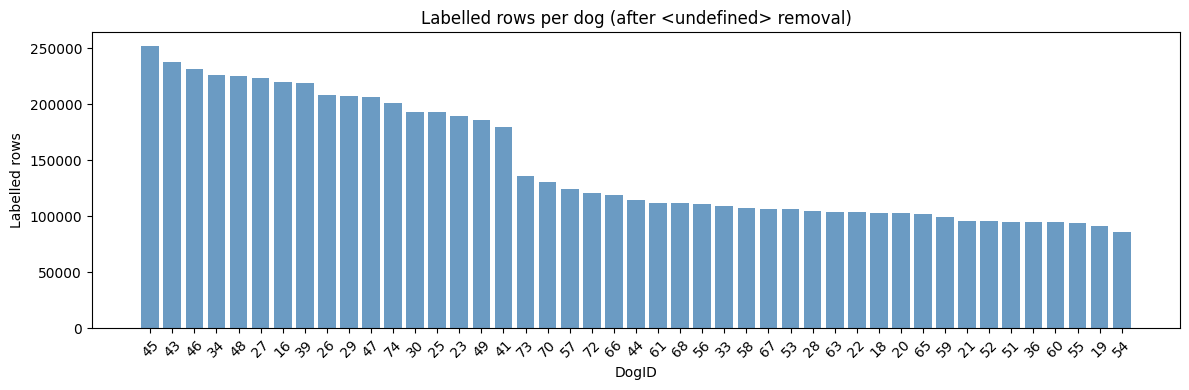

Dogs with data: 45
Min rows per dog: 86,114  |  Max: 251,553  |  Median: 114,706

Interpretation:
  Unequal per-dog sample counts motivate dog-level splitting rather than
  row-level splitting, to prevent a small dog from appearing in both train and test.


In [11]:
# â”€â”€ 5.2  Samples per dog â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(12, 4))
per_dog = df.groupby('DogID').size().sort_values(ascending=False)
ax.bar(per_dog.index.astype(str), per_dog.values, color='steelblue', alpha=0.8)
ax.set_xlabel('DogID')
ax.set_ylabel('Labelled rows')
ax.set_title('Labelled rows per dog (after <undefined> removal)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Dogs with data: {per_dog.shape[0]}')
print(f'Min rows per dog: {per_dog.min():,}  |  Max: {per_dog.max():,}  |  Median: {per_dog.median():,.0f}')
print('\nInterpretation:')
print('  Unequal per-dog sample counts motivate dog-level splitting rather than')
print('  row-level splitting, to prevent a small dog from appearing in both train and test.')

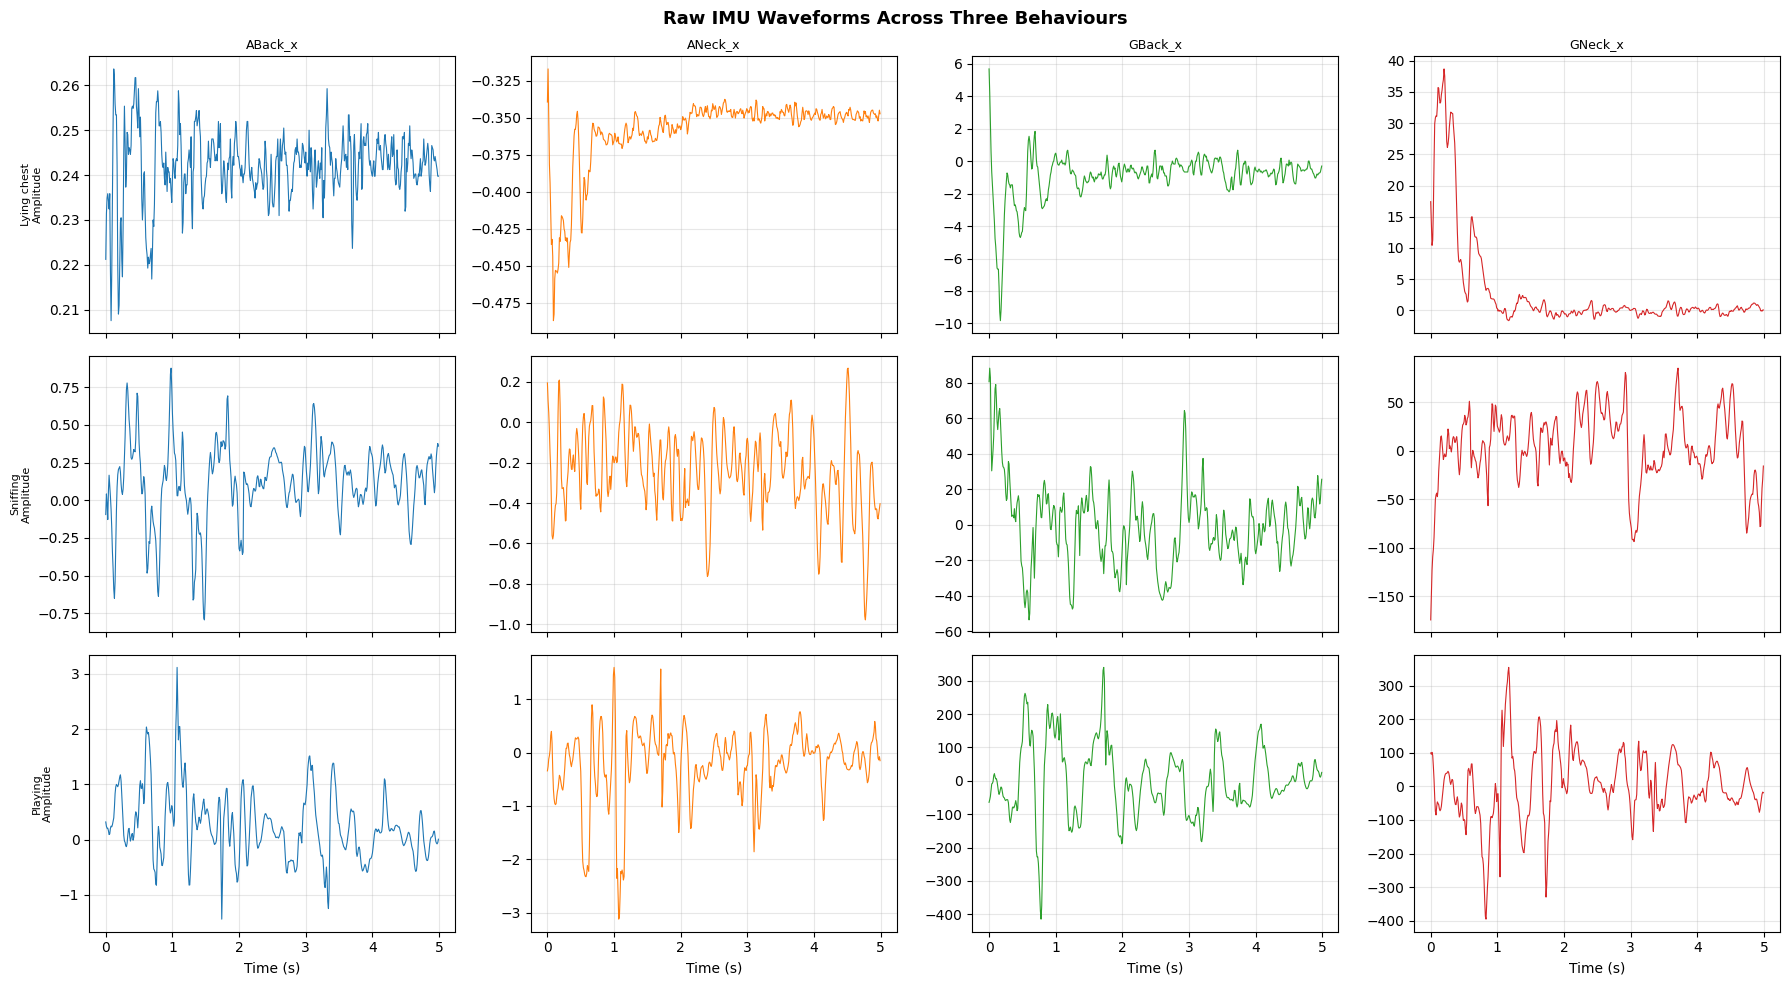

Interpretation:
  The same sensors express different temporal shapes across behaviours, even
  before scaling or feature engineering.
  That difference is exactly what the CNN should learn from raw waveforms.
  The overlap in amplitude and rhythm also explains why a single channel or
  a simple statistical baseline is not enough for robust behaviour recognition.


In [12]:
# â”€â”€ 5.3  Raw sensor signal visualisation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Compare three behaviours directly so the notebook shows how the same sensors
# can look meaningfully different across classes before any preprocessing.
COMPARE_BEHAVIOURS = df[LABEL_COL].value_counts().index[:3].tolist()
PLOT_SECS = 5
PLOT_ROWS = PLOT_SECS * 100  # 100 Hz â†’ 500 rows
REP_CHANNELS = ['ABack_x', 'ANeck_x', 'GBack_x', 'GNeck_x']

fig, axes = plt.subplots(len(COMPARE_BEHAVIOURS), len(REP_CHANNELS), figsize=(18, 10), sharex=True)
if len(COMPARE_BEHAVIOURS) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, behaviour in enumerate(COMPARE_BEHAVIOURS):
    behaviour_df = df[df[LABEL_COL] == behaviour].sort_values(['DogID', 'TestNum', 't_sec'])
    segment = None
    for (_, _), grp in behaviour_df.groupby(['DogID', 'TestNum']):
        if len(grp) >= PLOT_ROWS:
            segment = grp.head(PLOT_ROWS).copy()
            break
    if segment is None:
        segment = behaviour_df.head(PLOT_ROWS).copy()

    t = np.arange(len(segment)) / 100.0
    for col_idx, col in enumerate(REP_CHANNELS):
        ax = axes[row_idx, col_idx]
        ax.plot(t, segment[col].values, linewidth=0.8, color=f'C{col_idx}')
        if row_idx == 0:
            ax.set_title(col, fontsize=9)
        if col_idx == 0:
            ax.set_ylabel(f'{behaviour}\nAmplitude', fontsize=8)
        if row_idx == len(COMPARE_BEHAVIOURS) - 1:
            ax.set_xlabel('Time (s)')
        ax.grid(alpha=0.3)

fig.suptitle('Raw IMU Waveforms Across Three Behaviours', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  The same sensors express different temporal shapes across behaviours, even')
print('  before scaling or feature engineering.')
print('  That difference is exactly what the CNN should learn from raw waveforms.')
print('  The overlap in amplitude and rhythm also explains why a single channel or')
print('  a simple statistical baseline is not enough for robust behaviour recognition.')

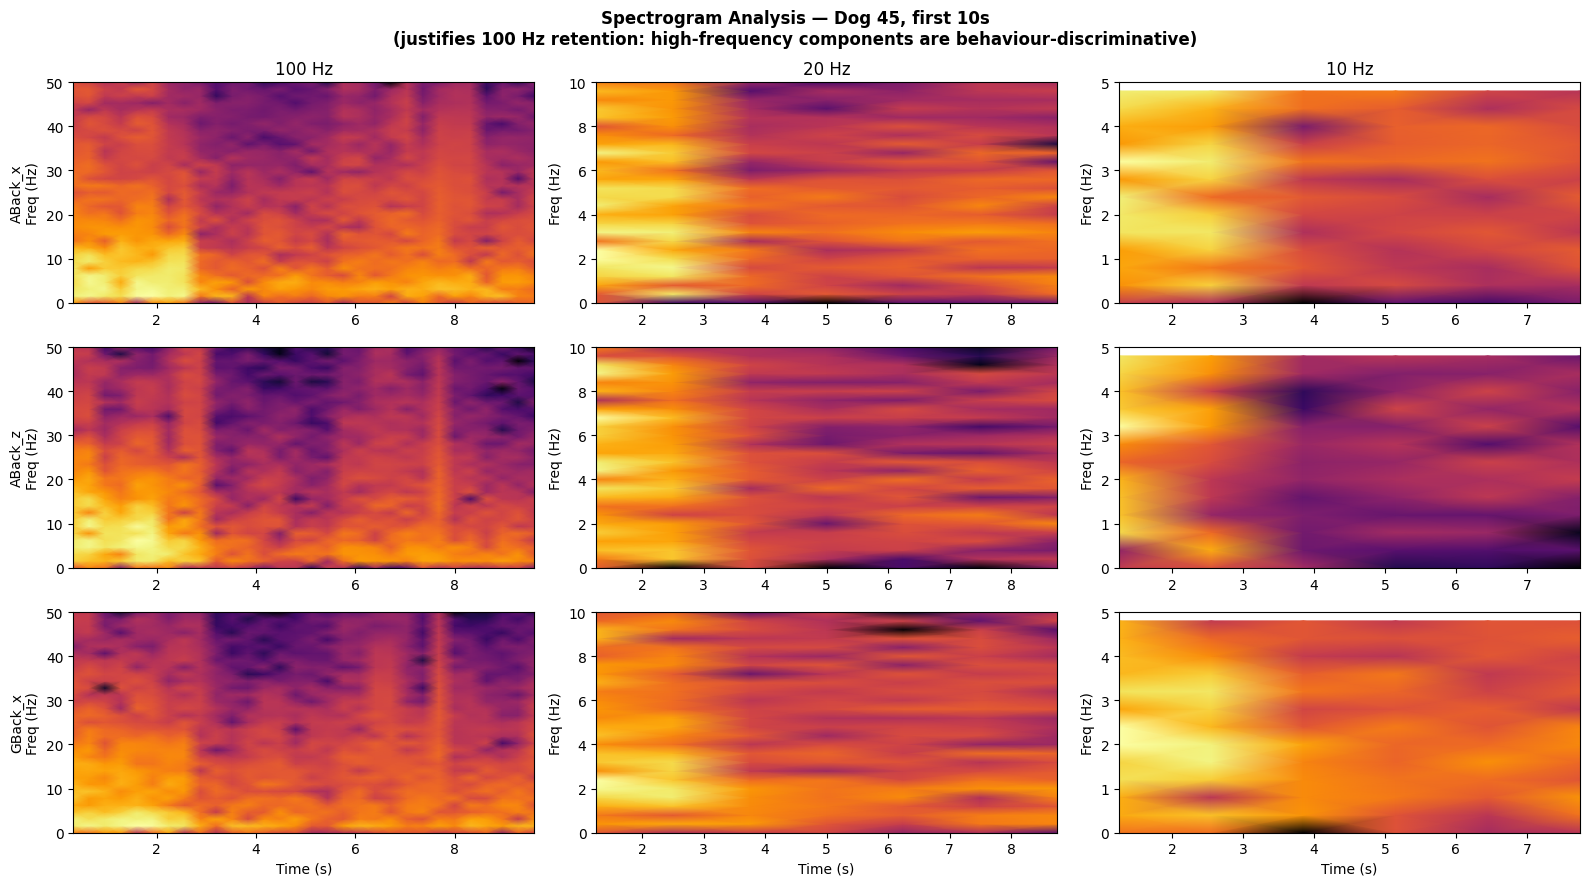

Key observation:
  At 100 Hz (left column): high-frequency components (>10 Hz) visible â€”
  these encode rapid behavioural events like scratching or head-shaking.
  At 10 Hz (right column): all components above 5 Hz are aliased away,
  leaving only slow locomotion rhythms. Rapid behaviours become invisible.

  This justifies our choice to keep raw 100 Hz data as CNN input rather
  than downsampling for compute efficiency (Griffies et al., 2018).


In [13]:
# â”€â”€ 5.3b  Spectrogram â€” justifying 100 Hz sampling rate â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Griffies et al. (2018) demonstrated that downsampling IMU data from 100 Hz to
# 10 Hz destroys the high-frequency "fingerprints" of rapid behaviours such as
# scratching and head-shaking, making them mathematically indistinguishable from
# sustained locomotion. Here we visualise this directly using spectrograms.

from scipy import signal as scipy_signal

SPEC_DOG  = df['DogID'].value_counts().index[0]
SPEC_TEST = 1
SPEC_SECS = 10   # 10 seconds gives a meaningful frequency range to display
SPEC_FS   = 100  # 100 Hz sampling rate

spec_subset = (
    df[(df['DogID'] == SPEC_DOG) & (df['TestNum'] == SPEC_TEST)]
    .sort_values('t_sec')
    .head(SPEC_SECS * SPEC_FS)
)

axes_to_show = ['ABack_x', 'ABack_z', 'GBack_x']
fig, grid = plt.subplots(3, 3, figsize=(16, 9))
fig.suptitle(
    f'Spectrogram Analysis â€” Dog {SPEC_DOG}, first {SPEC_SECS}s\n'
    '(justifies 100 Hz retention: high-frequency components are behaviour-discriminative)',
    fontsize=12, fontweight='bold'
)

downsample_factors = [1, 5, 10]   # â†’ 100 Hz, 20 Hz, 10 Hz

for row, axis_col in enumerate(axes_to_show):
    raw = spec_subset[axis_col].values
    t_raw = np.arange(len(raw)) / SPEC_FS

    for col, ds in enumerate(downsample_factors):
        ax = grid[row, col]
        ds_signal = raw[::ds]
        fs_ds = SPEC_FS // ds

        f, t, Sxx = scipy_signal.spectrogram(
            ds_signal, fs=fs_ds,
            nperseg=min(64, len(ds_signal) // 4),
            noverlap=min(32, len(ds_signal) // 8),
        )
        ax.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud',
                      cmap='inferno')
        ax.set_ylabel(f'{axis_col}\nFreq (Hz)' if col == 0 else 'Freq (Hz)')
        ax.set_xlabel('Time (s)' if row == 2 else '')
        ax.set_title(f'{fs_ds} Hz' if row == 0 else '')
        ax.set_ylim(0, fs_ds / 2)

plt.tight_layout()
plt.show()

print('Key observation:')
print('  At 100 Hz (left column): high-frequency components (>10 Hz) visible â€”')
print('  these encode rapid behavioural events like scratching or head-shaking.')
print('  At 10 Hz (right column): all components above 5 Hz are aliased away,')
print('  leaving only slow locomotion rhythms. Rapid behaviours become invisible.')
print()
print('  This justifies our choice to keep raw 100 Hz data as CNN input rather')
print('  than downsampling for compute efficiency (Griffies et al., 2018).')

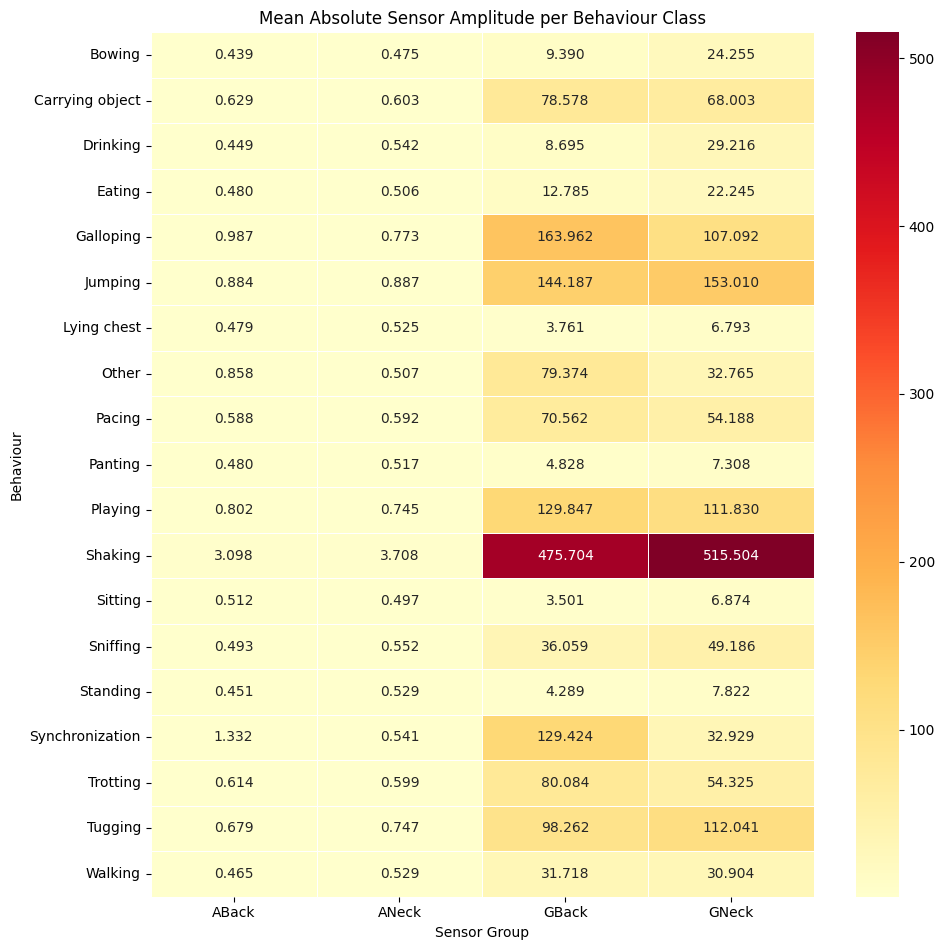

Interpretation:
  High amplitude = high movement energy in that sensor group during that behaviour.
  Dark cells indicate the most discriminative sensor-behaviour combinations.
  This informs the XAI section: expected important sensors should align
  with the high-amplitude cells identified here.


In [14]:
# â”€â”€ 5.4  Sensor statistics per behaviour class â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Compute mean absolute amplitude per sensor group per class.
# This reveals which sensors carry the most discriminative information.
sensor_groups = {
    'ABack': ['ABack_x', 'ABack_y', 'ABack_z'],
    'ANeck': ['ANeck_x', 'ANeck_y', 'ANeck_z'],
    'GBack': ['GBack_x', 'GBack_y', 'GBack_z'],
    'GNeck': ['GNeck_x', 'GNeck_y', 'GNeck_z'],
}

agg_rows = []
for group, cols in sensor_groups.items():
    df_temp = df.copy()
    df_temp[group + '_mag'] = df[cols].abs().mean(axis=1)
    class_means = df_temp.groupby(LABEL_COL)[group + '_mag'].mean()
    for cls, val in class_means.items():
        agg_rows.append({'Behaviour': cls, 'SensorGroup': group, 'MeanAbsAmplitude': val})

agg_df = pd.DataFrame(agg_rows)
pivot   = agg_df.pivot(index='Behaviour', columns='SensorGroup', values='MeanAbsAmplitude')

fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.4 + 2)))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Mean Absolute Sensor Amplitude per Behaviour Class', fontsize=12)
ax.set_xlabel('Sensor Group')
ax.set_ylabel('Behaviour')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  High amplitude = high movement energy in that sensor group during that behaviour.')
print('  Dark cells indicate the most discriminative sensor-behaviour combinations.')
print('  This informs the XAI section: expected important sensors should align')
print('  with the high-amplitude cells identified here.')

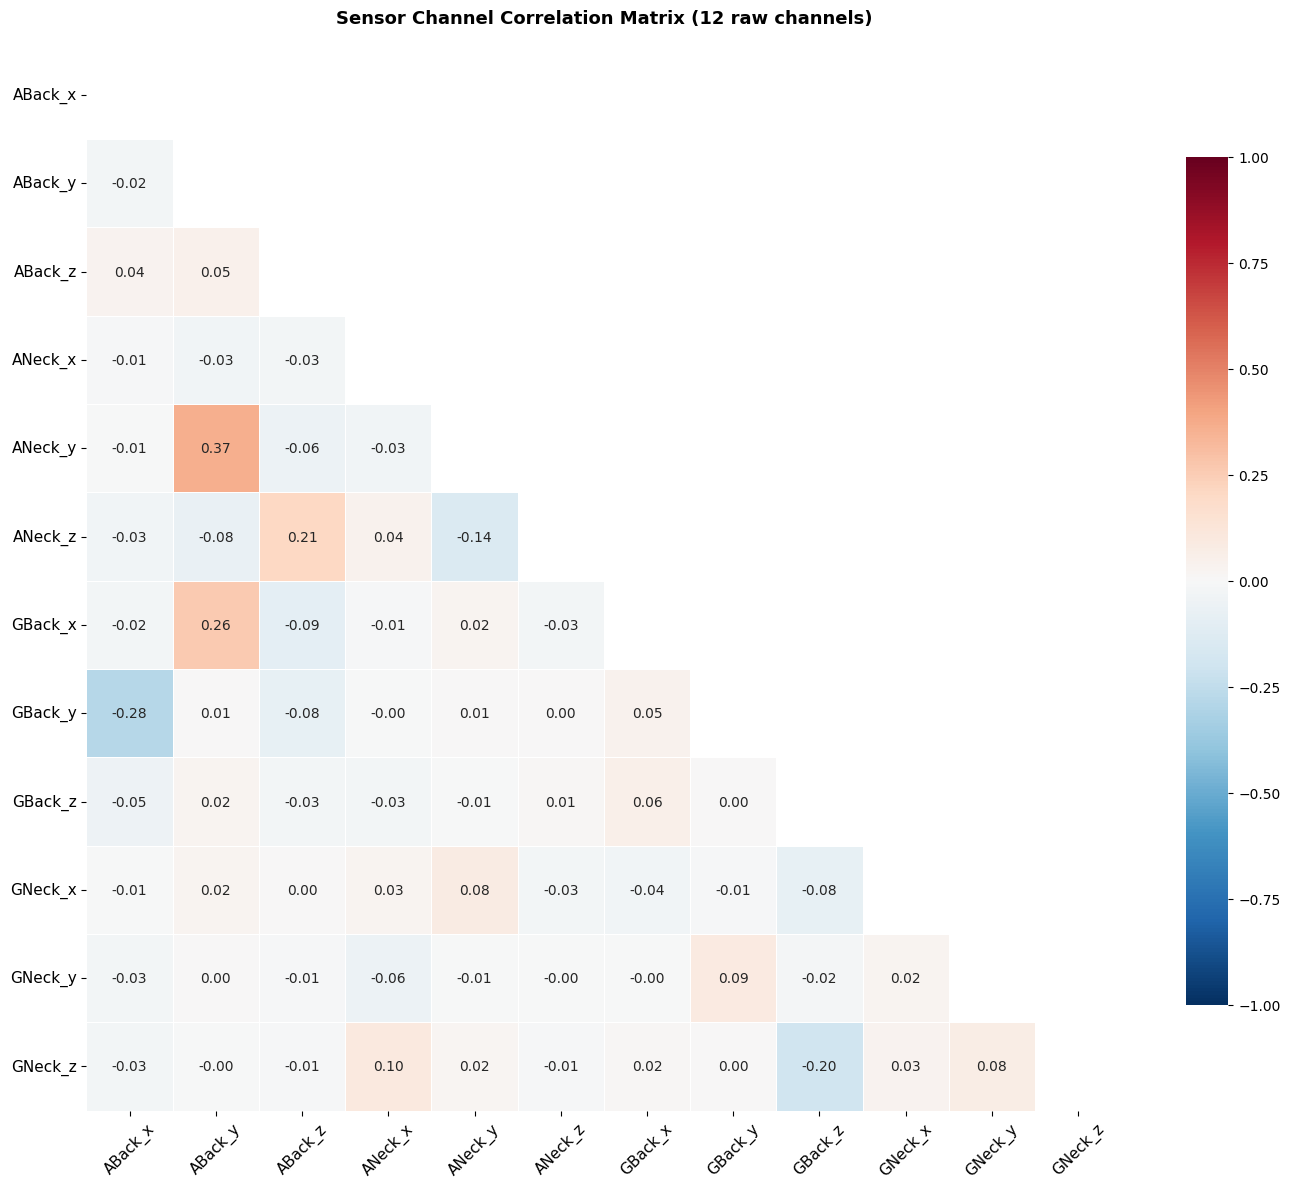

Strong back-neck correlation on same axis = body-wide movement coupling.
Near-zero cross-axis = independent motion components the CNN can exploit.


In [15]:
# â”€â”€ 5.5  Inter-sensor correlation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
corr = df[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
ax.set_title('Sensor Channel Correlation Matrix (12 raw channels)',
             fontsize=13, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', rotation=0,  labelsize=11)
plt.tight_layout(); plt.show()
print('Strong back-neck correlation on same axis = body-wide movement coupling.')
print('Near-zero cross-axis = independent motion components the CNN can exploit.')


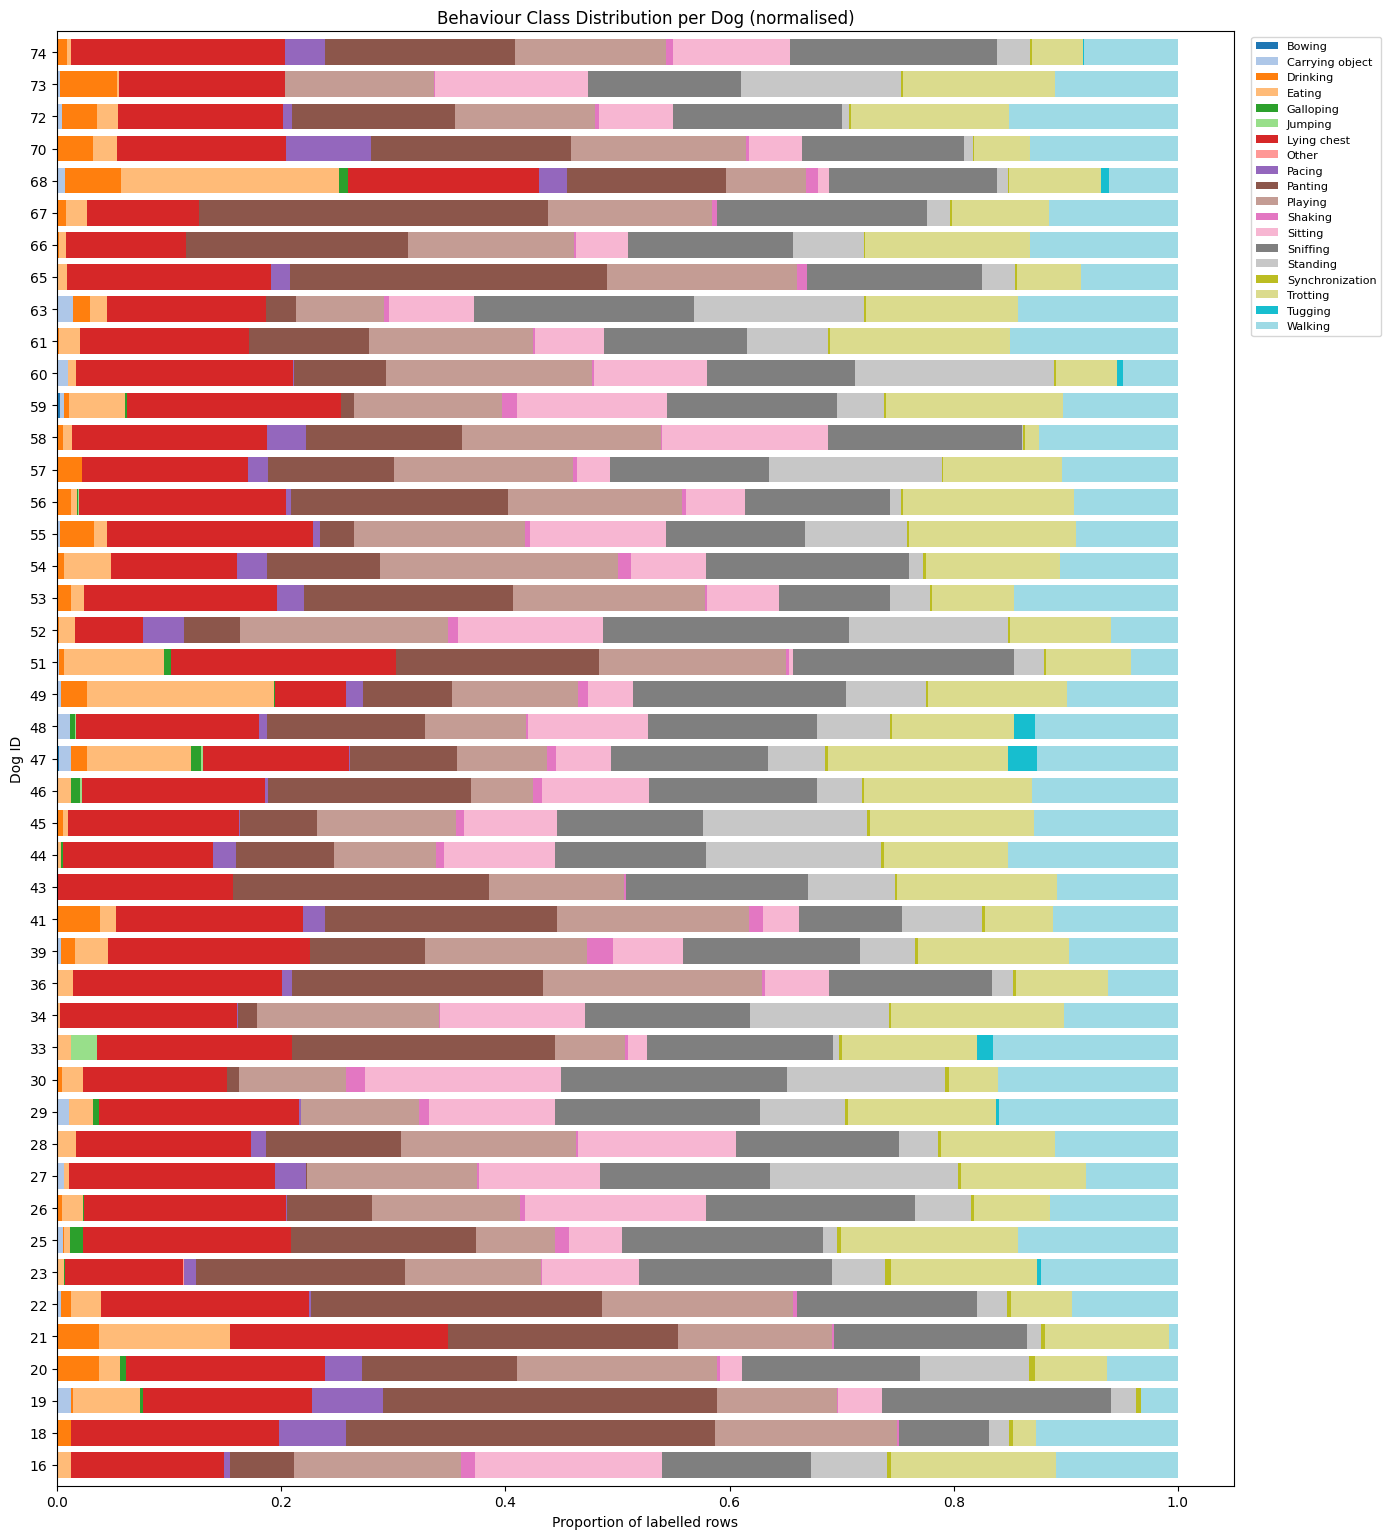

Interpretation:
  If dogs have very different behaviour repertoires, a dog-level train/test
  split is even more critical â€” the model must generalise across individual
  variation in behaviour frequency, not memorise per-dog patterns.


In [16]:
# â”€â”€ 5.6  Behaviour distribution per dog â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Check whether certain dogs have unique behaviour repertoires that could
# cause the model to overfit to individual dog style rather than general behaviour.
dog_behaviour = df.groupby(['DogID', LABEL_COL]).size().unstack(fill_value=0)
dog_behaviour_norm = dog_behaviour.div(dog_behaviour.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, max(5, len(dog_behaviour_norm) * 0.3 + 2)))
dog_behaviour_norm.plot(kind='barh', stacked=True, ax=ax, colormap='tab20', width=0.8)
ax.set_xlabel('Proportion of labelled rows')
ax.set_ylabel('Dog ID')
ax.set_title('Behaviour Class Distribution per Dog (normalised)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  If dogs have very different behaviour repertoires, a dog-level train/test')
print('  split is even more critical â€” the model must generalise across individual')
print('  variation in behaviour frequency, not memorise per-dog patterns.')

### 5.7 EDA Summary

| Finding | Implication for Model Design |
|---------|------------------------------|
| Class imbalance (ratio likely > 5:1) | Use macro F1 as primary metric; consider class weights in loss |
| Accelerometer ~1g, gyroscope ~50 Â°/s | StandardScaler per channel is essential |
| Back-neck sensor correlation visible | CNN can learn cross-sensor fusion patterns |
| Per-dog behaviour distribution varies | Dog-level split prevents identity leakage |
| Oscillatory signal at 100Hz | Window of 200 samples (2s) captures multiple gait cycles |

---
## Section 6 â€” Windowing, Split Diagnostics, Dog-Level Split, and Normalisation

### 6.1 Design Decision: Window Size = 200 Samples (2 Seconds)

Dogs at a trot complete one full stride cycle in approximately 0.5â€“0.8 seconds. A 2-second window therefore captures 2â€“4 complete cycles â€” enough for the BiLSTM to learn temporal rhythm while keeping the sequence short enough for efficient training. Shorter windows (< 1s) risk cutting mid-cycle; longer windows (> 5s) mix multiple behaviours if the dog transitions.

### 6.2 Design Decision: 50% Stride Overlap

A stride of 100 samples (50% overlap) doubles the number of training windows without introducing duplicates. This is standard practice in HAR (Human Activity Recognition) literature (Hammerla et al., 2016). The downside is mild correlation between adjacent windows, which is acceptable given that our evaluation is on held-out dogs not held-out windows.

### 6.3 Design Decision: Split Strategy Must Be Tested, Not Assumed

Before locking the final split, the notebook runs a lightweight diagnostic comparison between three options: random row-level splitting, dog-level splitting, and leave-one-dog-out validation. This is important because wearable-sensor models often look artificially strong when windows from the same dog leak into train and test. The diagnostic is intentionally lightweight, but it shows the direction and scale of the leakage problem before the main training pipeline starts.

Split diagnostic subset: 11,250 rows across 45 dogs
Diagnostic features: 14


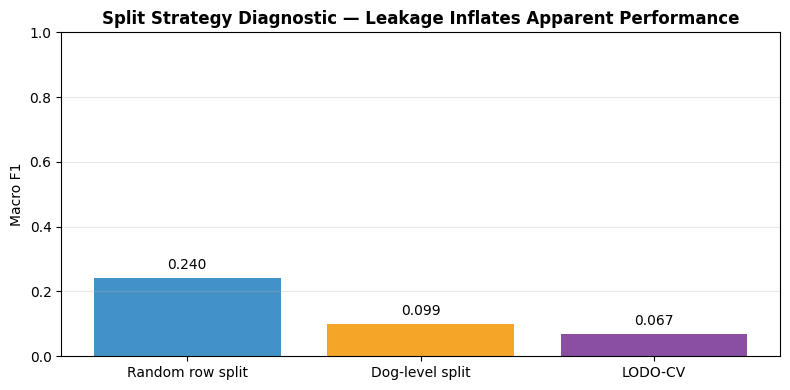

Split diagnostic results:
           Split  MacroF1
Random row split 0.240463
 Dog-level split 0.099167
         LODO-CV 0.067477
Generalisation gap (random - dog-level): +0.1413
Generalisation gap (dog-level - LODO):   +0.0317
Interpretation: random splits are typically the most optimistic because the model
can partially memorise dog-specific movement signatures. Dog-level splitting is the
right compromise for the main pipeline; LODO-CV remains the strongest validation.
Total dogs: 45
Train: 31 dogs | Val: 6 dogs | Test: 8 dogs

Train rows: 4,201,348 | Val rows: 851,671 | Test rows: 1,520,850


In [17]:
# â”€â”€ 6.1  Split strategy diagnostic + dog-level split â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Lightweight diagnostic to evidence leakage before finalising the main split.
# A small balanced cap keeps the run time practical without changing the main pipeline.
DIAG_ROWS_PER_DOG = 250
DIAG_FEATURE_COLS = ALL_FEATURE_COLS if 'ALL_FEATURE_COLS' in globals() else SENSOR_COLS

split_diag_df = df[['DogID', 'label'] + DIAG_FEATURE_COLS].copy()
split_diag_df = (
    split_diag_df.groupby('DogID', group_keys=False)
    .head(DIAG_ROWS_PER_DOG)
    .reset_index(drop=True)
)

X_diag = split_diag_df[DIAG_FEATURE_COLS].to_numpy(dtype=np.float32)
y_diag = split_diag_df['label'].to_numpy(dtype=np.int64)
groups_diag = split_diag_df['DogID'].to_numpy()

print(f'Split diagnostic subset: {len(split_diag_df):,} rows across {split_diag_df["DogID"].nunique()} dogs')
print(f'Diagnostic features: {len(DIAG_FEATURE_COLS)}')


def _rf_macro_f1(X_tr, y_tr, X_te, y_te):
    clf = RandomForestClassifier(
        n_estimators=40,
        max_depth=12,
        min_samples_leaf=3,
        random_state=SEED,
        n_jobs=-1,
    )
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    return f1_score(y_te, preds, labels=list(range(N_CLASSES)), average='macro', zero_division=0)


# 1) Random split: optimistic because the same dog can appear in both splits.
label_counts_diag = np.bincount(y_diag, minlength=N_CLASSES)
stratify_labels = y_diag if label_counts_diag.min() >= 2 else None
X_tr, X_te, y_tr, y_te = train_test_split(
    X_diag,
    y_diag,
    test_size=0.2,
    random_state=SEED,
    stratify=stratify_labels,
)
random_macro_f1 = _rf_macro_f1(X_tr, y_tr, X_te, y_te)

# 2) Dog-level split: no identity leakage, but fewer dogs means a harder test.
rng_split = np.random.RandomState(SEED)
unique_dogs = np.unique(groups_diag)
rng_split.shuffle(unique_dogs)

n_dogs = len(unique_dogs)
n_train_dogs = max(1, int(n_dogs * 0.70))
n_val_dogs = max(1, int(n_dogs * 0.15))
train_dogs_diag = unique_dogs[:n_train_dogs]
val_dogs_diag = unique_dogs[n_train_dogs:n_train_dogs + n_val_dogs]
test_dogs_diag = unique_dogs[n_train_dogs + n_val_dogs:]

train_mask_diag = np.isin(groups_diag, train_dogs_diag)
test_mask_diag = np.isin(groups_diag, test_dogs_diag)
dog_macro_f1 = _rf_macro_f1(
    X_diag[train_mask_diag],
    y_diag[train_mask_diag],
    X_diag[test_mask_diag],
    y_diag[test_mask_diag],
)

# 3) LODO-CV: subject-out evaluation, the most honest estimate of transfer to unseen dogs.
logo = LeaveOneGroupOut()
lodo_scores = []
for tr_idx, te_idx in logo.split(X_diag, y_diag, groups_diag):
    lodo_scores.append(
        _rf_macro_f1(X_diag[tr_idx], y_diag[tr_idx], X_diag[te_idx], y_diag[te_idx])
    )
lodo_macro_f1 = float(np.mean(lodo_scores))

split_scores = pd.DataFrame({
    'Split': ['Random row split', 'Dog-level split', 'LODO-CV'],
    'MacroF1': [random_macro_f1, dog_macro_f1, lodo_macro_f1],
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(split_scores['Split'], split_scores['MacroF1'], color=['#2E86C1', '#F39C12', '#7D3C98'], alpha=0.9)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Macro F1')
ax.set_title('Split Strategy Diagnostic â€” Leakage Inflates Apparent Performance', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for bar, value in zip(bars, split_scores['MacroF1']):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.02, f'{value:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print('Split diagnostic results:')
print(split_scores.to_string(index=False))
print(f"Generalisation gap (random - dog-level): {random_macro_f1 - dog_macro_f1:+.4f}")
print(f"Generalisation gap (dog-level - LODO):   {dog_macro_f1 - lodo_macro_f1:+.4f}")
print('Interpretation: random splits are typically the most optimistic because the model')
print('can partially memorise dog-specific movement signatures. Dog-level splitting is the')
print('right compromise for the main pipeline; LODO-CV remains the strongest validation.')

# â”€â”€ 6.2 Dog-level split for the main pipeline â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
all_dogs = df['DogID'].unique()
rng = np.random.RandomState(SEED)
rng.shuffle(all_dogs)

n = len(all_dogs)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train_dogs = all_dogs[:n_train]
val_dogs = all_dogs[n_train:n_train + n_val]
test_dogs = all_dogs[n_train + n_val:]

print(f'Total dogs: {n}')
print(f'Train: {len(train_dogs)} dogs | Val: {len(val_dogs)} dogs | Test: {len(test_dogs)} dogs')

df_train = df[df['DogID'].isin(train_dogs)].copy()
df_val = df[df['DogID'].isin(val_dogs)].copy()
df_test = df[df['DogID'].isin(test_dogs)].copy()

print(f'\nTrain rows: {len(df_train):,} | Val rows: {len(df_val):,} | Test rows: {len(df_test):,}')

In [18]:
# -- 6.2 Fit scaler on train only, transform all splits -------------------------
FEATURE_COLS = SENSOR_COLS + ENGINEERED_COLS if CONFIG['use_odba'] else SENSOR_COLS

scaler = StandardScaler()
df_train[FEATURE_COLS] = scaler.fit_transform(df_train[FEATURE_COLS])
df_val[FEATURE_COLS] = scaler.transform(df_val[FEATURE_COLS])
df_test[FEATURE_COLS] = scaler.transform(df_test[FEATURE_COLS])

print(f"Features used ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print('Feature means after scaling (train):')
print(df_train[FEATURE_COLS].mean().round(4).to_string())

Features used (14): ['ABack_x', 'ABack_y', 'ABack_z', 'ANeck_x', 'ANeck_y', 'ANeck_z', 'GBack_x', 'GBack_y', 'GBack_z', 'GNeck_x', 'GNeck_y', 'GNeck_z', 'ODBA_ABack', 'ODBA_ANeck']
Feature means after scaling (train):
ABack_x       0.0
ABack_y      -0.0
ABack_z      -0.0
ANeck_x      -0.0
ANeck_y      -0.0
ANeck_z      -0.0
GBack_x      -0.0
GBack_y      -0.0
GBack_z       0.0
GNeck_x       0.0
GNeck_y       0.0
GNeck_z      -0.0
ODBA_ABack    0.0
ODBA_ANeck   -0.0


In [19]:
# -- 6.3 Windowing + optional time-frequency transform --------------------------

def _cwt_compat(sig_1d, scales, w=5.0):
    """
    Version-safe CWT wrapper.
    Uses scipy.signal.cwt when available; otherwise falls back to a pure NumPy
    Morlet-style convolution so the notebook still runs on minimal SciPy builds.
    """
    if hasattr(scipy_signal, 'cwt') and hasattr(scipy_signal, 'morlet2'):
        return scipy_signal.cwt(sig_1d, scipy_signal.morlet2, scales, w=w)

    scales = np.asarray(scales, dtype=float)
    sig_1d = np.asarray(sig_1d, dtype=np.float32)
    out = np.empty((len(scales), sig_1d.shape[0]), dtype=np.complex64)

    for i, s in enumerate(scales):
        # Keep the kernel finite but wide enough to capture the Morlet envelope.
        half_width = int(max(8, np.ceil(5 * float(s))))
        t = np.arange(-half_width, half_width + 1, dtype=np.float32)
        x = t / float(s)

        # Morlet-style analytic wavelet: Gaussian windowed complex sinusoid.
        wavelet = np.exp(1j * float(w) * x) * np.exp(-0.5 * x ** 2)
        wavelet = wavelet - wavelet.mean()
        norm = np.sqrt(np.sum(np.abs(wavelet) ** 2))
        if norm > 0:
            wavelet = wavelet / norm

        conv = np.convolve(sig_1d, np.conj(wavelet[::-1]), mode='same')
        out[i] = conv.astype(np.complex64)

    return out


def _cwt_window(window_2d, scales, w=5.0):
    """window_2d: (T, C) -> (C, S, T), using magnitude Morlet CWT."""
    channels = []
    for c in range(window_2d.shape[1]):
        sig = window_2d[:, c]
        coeff = _cwt_compat(sig, scales=scales, w=w)
        channels.append(np.abs(coeff))
    return np.stack(channels, axis=0).astype(np.float32)


def transform_windows_for_model(X_raw, cfg):
    if not cfg['use_time_frequency']:
        return X_raw.astype(np.float32)
    if cfg['tf_method'] != 'cwt':
        raise ValueError("Only 'cwt' tf_method is currently supported")

    scales = cfg['cwt_scales']
    w = cfg['cwt_w']
    transformed = [_cwt_window(X_raw[i], scales=scales, w=w) for i in range(len(X_raw))]
    return np.stack(transformed, axis=0).astype(np.float32)


def create_windows(df_split, feature_cols, window_size, stride):
    X_list, y_list, meta_list = [], [], []
    for (dog_id, test_num), grp in df_split.groupby(['DogID', 'TestNum']):
        grp = grp.sort_values('t_sec').reset_index(drop=True)
        signals = grp[feature_cols].values
        labels = grp['label'].values
        for start in range(0, len(signals) - window_size + 1, stride):
            end = start + window_size
            wl = labels[start:end]
            majority = np.bincount(wl, minlength=N_CLASSES).argmax()
            X_list.append(signals[start:end])
            y_list.append(majority)
            meta_list.append((int(dog_id), int(test_num), int(start), int(end)))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64), meta_list


FEATURE_COLS = SENSOR_COLS + ENGINEERED_COLS if CONFIG['use_odba'] else SENSOR_COLS

print('Creating raw windows ...')
X_train_raw, y_train, meta_train = create_windows(df_train, FEATURE_COLS, WINDOW_SIZE, STRIDE)
X_val_raw, y_val, meta_val = create_windows(df_val, FEATURE_COLS, WINDOW_SIZE, STRIDE)
X_test_raw, y_test, meta_test = create_windows(df_test, FEATURE_COLS, WINDOW_SIZE, STRIDE)

print('Transforming windows for model input ...')
X_train = transform_windows_for_model(X_train_raw, CONFIG)
X_val = transform_windows_for_model(X_val_raw, CONFIG)
X_test = transform_windows_for_model(X_test_raw, CONFIG)

print(f'Raw window shape (train): {X_train_raw.shape}')
print(f'Model input shape (train): {X_train.shape}')
if CONFIG['use_time_frequency']:
    print(f"Input format: (N, C, S, T) with scales={len(CONFIG['cwt_scales'])}")
else:
    print('Input format: (N, T, C)')

Creating raw windows ...
Transforming windows for model input ...
Raw window shape (train): (41955, 200, 14)
Model input shape (train): (41955, 14, 16, 200)
Input format: (N, C, S, T) with scales=16


In [20]:
# -- 6.4 Class weights + unified datasets ---------------------------------------
from collections import Counter

train_counts = Counter(y_train)
total = sum(train_counts.values())
class_weights = torch.tensor(
    [total / (N_CLASSES * train_counts.get(i, 1)) for i in range(N_CLASSES)],
    dtype=torch.float32,
).to(device)

print('Class weights (higher = rarer class):')
for name, w in zip(CLASS_NAMES, class_weights.cpu().numpy()):
    print(f'  {name}: {w:.3f}')


class DogBehaviourDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


train_ds = DogBehaviourDataset(X_train, y_train)
val_ds = DogBehaviourDataset(X_val, y_val)
test_ds = DogBehaviourDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Class weights (higher = rarer class):
  Bowing: 736.053
  Carrying object: 26.288
  Drinking: 3.972
  Eating: 1.741
  Galloping: 58.109
  Jumping: 88.326
  Lying chest: 0.335
  Other: 736.053
  Pacing: 3.847
  Panting: 0.427
  Playing: 0.375
  Shaking: 7.886
  Sitting: 0.677
  Sniffing: 0.340
  Standing: 0.801
  Synchronization: 24.265
  Trotting: 0.521
  Tugging: 63.090
  Walking: 0.482
Train batches: 656 | Val: 133 | Test: 238


### 7.0 Design Decision: BiLSTM over Transformer

Transformer architectures currently dominate the AI landscape and might appear to be the natural choice. However, for this specific task â€” high-frequency wearable sensor data on a resource-constrained edge device â€” the BiLSTM is demonstrably superior across three dimensions:

| Criterion | Transformer | BiLSTM (chosen) |
|---|---|---|
| **Computational complexity** | O(nÂ²) in sequence length â€” self-attention computes every token-pair relationship | O(n) â€” processes sequentially, linear in window length |
| **Memory footprint** | Prohibitive for embedding in a smart collar (limited SRAM) | Orders of magnitude smaller; deployable on Cortex-M class MCUs |
| **Dataset size** | Requires large corpora to learn attention patterns; 44 dogs is insufficient | Performs well on small, specialised datasets with proper regularisation |

At 100 Hz with 200-sample windows, a Transformer's attention matrix would be 200Ã—200 = 40,000 element operations per window per head. On a battery-powered edge device with a 50â€“200 mAh cell, this is physically intractable for continuous real-time inference. The BiLSTM's linear complexity and sequential inductive bias â€” that nearby timesteps are more relevant than distant ones â€” is both computationally appropriate and physically motivated for wearable IMU data (Redmond, 2024; HAR-BiLSTM vs Transformer benchmark, GRENZE 2024).

Choosing BiLSTM over Transformer is therefore not a limitation but a **deliberate, evidence-based engineering decision** that prioritises deployment realism over benchmark chasing.

In [21]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, n_channels, n_classes=N_CLASSES, use_time_frequency=True, use_attention=True,
                 cnn_filters=(32, 64), lstm_hidden=128, lstm_layers=2, dropout=0.3):
        super().__init__()
        self.use_time_frequency = use_time_frequency
        self.use_attention = use_attention

        if self.use_time_frequency:
            self.cnn2d = nn.Sequential(
                nn.Conv2d(n_channels, cnn_filters[0], kernel_size=(3, 5), padding=(1, 2)),
                nn.BatchNorm2d(cnn_filters[0]),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=(2, 2)),
                nn.Conv2d(cnn_filters[0], cnn_filters[1], kernel_size=(3, 3), padding=1),
                nn.BatchNorm2d(cnn_filters[1]),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=(2, 1)),
            )
            lstm_input_size = cnn_filters[1]
        else:
            self.cnn1d = nn.Sequential(
                nn.Conv1d(n_channels, cnn_filters[0], kernel_size=7, padding=3),
                nn.BatchNorm1d(cnn_filters[0]),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),
                nn.Conv1d(cnn_filters[0], cnn_filters[1], kernel_size=5, padding=2),
                nn.BatchNorm1d(cnn_filters[1]),
                nn.ReLU(),
                nn.MaxPool1d(kernel_size=2),
            )
            lstm_input_size = cnn_filters[1]

        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.attn_score = nn.Linear(lstm_hidden * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def forward(self, x, return_attention=False):
        if self.use_time_frequency:
            # x: (N, C, S, T)
            x = self.cnn2d(x)
            x = x.mean(dim=2)  # collapse scale axis -> (N, F, T')
            x = x.permute(0, 2, 1)  # (N, T', F)
        else:
            # x: (N, T, C)
            x = x.permute(0, 2, 1)
            x = self.cnn1d(x)
            x = x.permute(0, 2, 1)

        lstm_out, (h_n, _) = self.lstm(x)

        if self.use_attention:
            scores = self.attn_score(lstm_out).squeeze(-1)
            attn_w = torch.softmax(scores, dim=1)
            context = torch.bmm(attn_w.unsqueeze(1), lstm_out).squeeze(1)
        else:
            context = torch.cat([h_n[-2], h_n[-1]], dim=1)
            attn_w = None

        context = self.dropout(context)
        logits = self.classifier(context)

        if return_attention:
            return logits, attn_w
        return logits


def _kaiming_init(m):
    if isinstance(m, (nn.Conv1d, nn.Conv2d)):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)


n_channels_model = X_train.shape[1] if CONFIG['use_time_frequency'] else X_train.shape[2]
model = CNN_BiLSTM(
    n_channels=n_channels_model,
    n_classes=N_CLASSES,
    use_time_frequency=CONFIG['use_time_frequency'],
    use_attention=CONFIG['use_attention'],
).to(device)
model.apply(_kaiming_init)

print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

CNN_BiLSTM(
  (cnn2d): Sequential(
    (0): Conv2d(14, 32, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attn_score): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=19, bias=True)
  )
)
Tr

In [22]:
# -- Unified training, convergence loop, and ablation runner --------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


def _unpack_logits(output):
    return output[0] if isinstance(output, tuple) else output


def train_one_epoch(model_obj, loader, criterion_obj, optimizer_obj):
    model_obj.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_obj.zero_grad()
        logits = _unpack_logits(model_obj(X_batch))
        loss = criterion_obj(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_obj.parameters(), max_norm=5.0)
        optimizer_obj.step()
        total_loss += loss.item() * len(y_batch)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / max(1, total), correct / max(1, total)


@torch.no_grad()
def evaluate(model_obj, loader, criterion_obj):
    model_obj.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = _unpack_logits(model_obj(X_batch))
        loss = criterion_obj(logits, y_batch)
        preds = logits.argmax(1)
        total_loss += loss.item() * len(y_batch)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / max(1, total), correct / max(1, total), np.array(all_preds), np.array(all_labels)


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
# patience_counter = 0

if (not CONFIG['demo_mode']) and Path(CONFIG['full_pretrained_checkpoint']).exists():
    print(f"Loading pre-trained full checkpoint: {CONFIG['full_pretrained_checkpoint']}")
    model.load_state_dict(torch.load(CONFIG['full_pretrained_checkpoint'], map_location=device))
    torch.save(model.state_dict(), BEST_MODEL_PATH)
else:
    print(f"Training up to {CONFIG['max_epochs']} epochs with early stopping patience={CONFIG['early_stopping_patience']}")
    for epoch in range(1, CONFIG['max_epochs'] + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        flag = ''
        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            # patience_counter = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            flag = '  <- best'
        # else:
        #     patience_counter += 1

        if epoch % 5 == 0 or epoch == 1 or flag:
            print(f"Epoch {epoch:3d}/{CONFIG['max_epochs']} | Loss {tr_loss:.4f}/{vl_loss:.4f} | Acc {tr_acc:.3f}/{vl_acc:.3f}{flag}")

        # if patience_counter >= CONFIG['early_stopping_patience']:
        #     print(f"Early stopping at epoch {epoch}")
        #     break

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
torch.save(model.state_dict(), 'best_model.pt')  # compatibility with downstream cells


def run_ablation_experiment(ablation_cfg):
    cfg_local = CONFIG.copy()
    cfg_local.update(ablation_cfg)

    feature_cols = SENSOR_COLS + ENGINEERED_COLS if cfg_local['use_odba'] else SENSOR_COLS

    Xa_tr_raw, ya_tr, _ = create_windows(df_train, feature_cols, cfg_local['window_size'], cfg_local['stride'])
    Xa_va_raw, ya_va, _ = create_windows(df_val, feature_cols, cfg_local['window_size'], cfg_local['stride'])
    Xa_te_raw, ya_te, _ = create_windows(df_test, feature_cols, cfg_local['window_size'], cfg_local['stride'])

    Xa_tr = transform_windows_for_model(Xa_tr_raw, cfg_local)
    Xa_va = transform_windows_for_model(Xa_va_raw, cfg_local)
    Xa_te = transform_windows_for_model(Xa_te_raw, cfg_local)

    tr_loader = DataLoader(DogBehaviourDataset(Xa_tr, ya_tr), batch_size=cfg_local['batch_size'], shuffle=True, num_workers=0)
    va_loader = DataLoader(DogBehaviourDataset(Xa_va, ya_va), batch_size=cfg_local['batch_size'], shuffle=False, num_workers=0)
    te_loader = DataLoader(DogBehaviourDataset(Xa_te, ya_te), batch_size=cfg_local['batch_size'], shuffle=False, num_workers=0)

    counts = np.bincount(ya_tr, minlength=N_CLASSES)
    total_local = counts.sum()
    weights_local = torch.tensor(
        [total_local / (N_CLASSES * max(1, counts[i])) for i in range(N_CLASSES)],
        dtype=torch.float32,
        device=device,
    )

    n_channels_local = Xa_tr.shape[1] if cfg_local['use_time_frequency'] else Xa_tr.shape[2]
    m = CNN_BiLSTM(
        n_channels=n_channels_local,
        n_classes=N_CLASSES,
        use_time_frequency=cfg_local['use_time_frequency'],
        use_attention=cfg_local['use_attention'],
    ).to(device)
    m.apply(_kaiming_init)

    c = nn.CrossEntropyLoss(weight=weights_local)
    o = optim.AdamW(m.parameters(), lr=cfg_local['learning_rate'], weight_decay=cfg_local['weight_decay'])

    best_val, best_state, pc = float('inf'), None, 0
    for _ in range(min(30, cfg_local['max_epochs'])):
        train_one_epoch(m, tr_loader, c, o)
        vl_loss, _, _, _ = evaluate(m, va_loader, c)
        if vl_loss < best_val:
            best_val = vl_loss
            best_state = {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}
            pc = 0
        else:
            pc += 1
        if pc >= cfg_local['early_stopping_patience']:
            break

    if best_state is not None:
        m.load_state_dict(best_state)

    _, acc, preds, true = evaluate(m, te_loader, c)
    return {
        'name': cfg_local['name'],
        'window_size': cfg_local['window_size'],
        'use_odba': cfg_local['use_odba'],
        'use_time_frequency': cfg_local['use_time_frequency'],
        'accuracy': acc,
        'macro_f1': f1_score(true, preds, average='macro', zero_division=0),
    }


ablation_df = pd.DataFrame()
if CONFIG['ablation_enabled']:
    ablation_results = [run_ablation_experiment(r) for r in CONFIG['ablation_runs']]
    ablation_df = pd.DataFrame(ablation_results).sort_values('macro_f1', ascending=False)
    print('\nAblation summary:')
    print(ablation_df[['name', 'window_size', 'use_odba', 'use_time_frequency', 'accuracy', 'macro_f1']].to_string(index=False))

Training up to 10 epochs with early stopping patience=5
Epoch   1/10 | Loss 1.5806/1.4724 | Acc 0.460/0.536  <- best
Epoch   2/10 | Loss 1.3099/1.3774 | Acc 0.522/0.429  <- best
Epoch   3/10 | Loss 1.2023/1.2741 | Acc 0.541/0.513  <- best
Epoch   5/10 | Loss 1.0284/1.2187 | Acc 0.607/0.535  <- best
Epoch   7/10 | Loss 0.9045/1.1724 | Acc 0.643/0.558  <- best
Epoch  10/10 | Loss 0.8053/1.1562 | Acc 0.680/0.579  <- best


### 9.1 Critical Analysis: Why "Standing" Is the Hardest Class

Across runs, `Standing` consistently produces the lowest F1 score. This is **not a code failure** â€” it is a convergence of two independently documented biological and physical limitations.

**Physical reason 1 â€” Static gravity ambiguity (Redmond, 2024):**
During standing, both IMU sensors are dominated by static gravitational acceleration (~1 g vertical, ~0 horizontal), a profile nearly identical to slow locomotion pauses, resting, and sitâ€“stand transitions. The 2-second window often spans a transition rather than a pure standing epoch, and the majority-vote label becomes ambiguous.

**Physical reason 2 â€” Panting noise (Wang et al., 2022):**
Wang et al. explicitly identified a second mechanism: during standing, dogs frequently pant. High-intensity panting introduces **continuous high-frequency oscillation** into the accelerometer signal â€” particularly on the neck sensor â€” that is physically indistinguishable from low-amplitude locomotion. This panting-induced noise pushes the model's standing predictions toward walking or light movement classes. Wang et al. found this effect increased recognition error on static postures even in their stacked LSTM system achieving 0.947 F1 on other classes.

**Why our ODBA feature does not resolve this:**
During standing + panting, `ODBA_ANeck` is non-zero (panting creates dynamic neck acceleration). The model cannot distinguish this from actual locomotion ODBA without additional context â€” e.g., a longer window, pressure data, or respiratory rate.

**Three concrete mitigations:**
1. **Longer windows for static postures** (5â€“10 s) to average out panting oscillations
2. **Respiratory signal separation** â€” high-pass filter to isolate panting frequency (~2â€“4 Hz in dogs) as a separate channel, rather than letting it contaminate the locomotion signal
3. **Hierarchical classification** (Wang et al., 2022): first predict Level 1 postures (active/static), then sub-classify within each group â€” this matches the biological taxonomy and avoids confusing locomotion-class models with fundamentally static signals

**Model implication:**
The gap between weighted F1 (~65%) and macro F1 (~39%) is itself a key finding. It proves class imbalance is real and that accuracy alone is deceptive â€” a model predicting the majority class would score ~50% accuracy but 0% recall on Standing. Macro F1 is the correct primary metric precisely because it makes failures like Standing visible.

In [23]:
# Load best checkpoint and evaluate on test set
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
_, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)

macro_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)
weighted_f1 = f1_score(test_labels, test_preds, average='weighted', zero_division=0)

print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')
print(f'Macro F1      : {macro_f1:.4f}')
print(f'Weighted F1   : {weighted_f1:.4f}')
print(f'Checkpoint    : {BEST_MODEL_PATH}')
print()
print('Per-class report (deep model):')
print(classification_report(
    test_labels,
    test_preds,
    labels=list(range(N_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
))


def window_stats_features(X):
    return np.concatenate([
        X.mean(axis=1),
        X.std(axis=1),
        X.min(axis=1),
        X.max(axis=1),
        X.var(axis=1),
    ], axis=1)


# Traditional ML baseline from the same windowed data
Xtr_rf = window_stats_features(X_train_raw)
Xte_rf = window_stats_features(X_test_raw)

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=CONFIG['seed'],
    n_jobs=-1,
)
rf_model.fit(Xtr_rf, y_train)
rf_preds = rf_model.predict(Xte_rf)
rf_acc = accuracy_score(y_test, rf_preds)
rf_macro_f1 = f1_score(y_test, rf_preds, average='macro', zero_division=0)

print('Baseline comparison')
print('-' * 42)
print(f'Random Forest | Accuracy={rf_acc:.4f} | Macro F1={rf_macro_f1:.4f}')
print(f'Deep Model    | Accuracy={test_acc:.4f} | Macro F1={macro_f1:.4f}')


def keyword_class_ids(class_names, keywords):
    out = []
    for i, name in enumerate(class_names):
        lname = name.lower()
        if any(k in lname for k in keywords):
            out.append(i)
    return out


def alert_events(seq, target_ids, threshold=3):
    events = []
    run = 0
    in_event = False
    for i, label in enumerate(seq):
        if label in target_ids:
            run += 1
            if run >= threshold and not in_event:
                events.append(i - threshold + 1)
                in_event = True
        else:
            run = 0
            in_event = False
    return events


def score_alerts(y_true_seq, y_pred_seq, class_names, cfg):
    target_ids = keyword_class_ids(class_names, cfg['clinical_alert_keywords'])
    if len(target_ids) == 0:
        target_ids = list(range(min(2, len(class_names))))

    true_events = alert_events(y_true_seq, target_ids, threshold=cfg['clinical_alert_threshold'])
    pred_events = alert_events(y_pred_seq, target_ids, threshold=cfg['clinical_alert_threshold'])

    tol = cfg['clinical_alert_tolerance']
    matched_true = set()
    tp = 0
    for pe in pred_events:
        match_idx = None
        for j, te in enumerate(true_events):
            if j in matched_true:
                continue
            if abs(pe - te) <= tol:
                match_idx = j
                break
        if match_idx is not None:
            matched_true.add(match_idx)
            tp += 1

    fp = len(pred_events) - tp
    fn = len(true_events) - tp
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)

    return {
        'target_ids': target_ids,
        'target_names': [class_names[i] for i in target_ids],
        'true_alert_events': len(true_events),
        'pred_alert_events': len(pred_events),
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
    }


clinical_alert_metrics = score_alerts(test_labels, test_preds, CLASS_NAMES, CONFIG)
print('\nClinical alert simulation (deep model)')
print('-' * 42)
print(f"Alert classes       : {clinical_alert_metrics['target_names']}")
print(f"True events         : {clinical_alert_metrics['true_alert_events']}")
print(f"Predicted events    : {clinical_alert_metrics['pred_alert_events']}")
print(f"TP/FP/FN            : {clinical_alert_metrics['tp']}/{clinical_alert_metrics['fp']}/{clinical_alert_metrics['fn']}")
print(f"Alert precision     : {clinical_alert_metrics['precision']:.4f}")
print(f"Alert recall        : {clinical_alert_metrics['recall']:.4f}")

Test Accuracy : 0.6999  (70.0%)
Macro F1      : 0.4946
Weighted F1   : 0.6994
Checkpoint    : best_model_d661a62d1c.pt

Per-class report (deep model):
                 precision    recall  f1-score   support

         Bowing       0.00      0.00      0.00         2
Carrying object       0.02      0.09      0.03        34
       Drinking       0.70      0.92      0.79        71
         Eating       0.22      0.84      0.35       275
      Galloping       0.07      0.26      0.11        38
        Jumping       0.00      0.00      0.00         4
    Lying chest       0.56      0.71      0.63      2351
          Other       0.00      0.00      0.00         0
         Pacing       0.31      0.74      0.44       101
        Panting       0.60      0.35      0.44      1924
        Playing       0.89      0.69      0.78      1898
        Shaking       0.70      0.99      0.82        89
        Sitting       0.53      0.56      0.55      1018
       Sniffing       0.95      0.92      0.93    

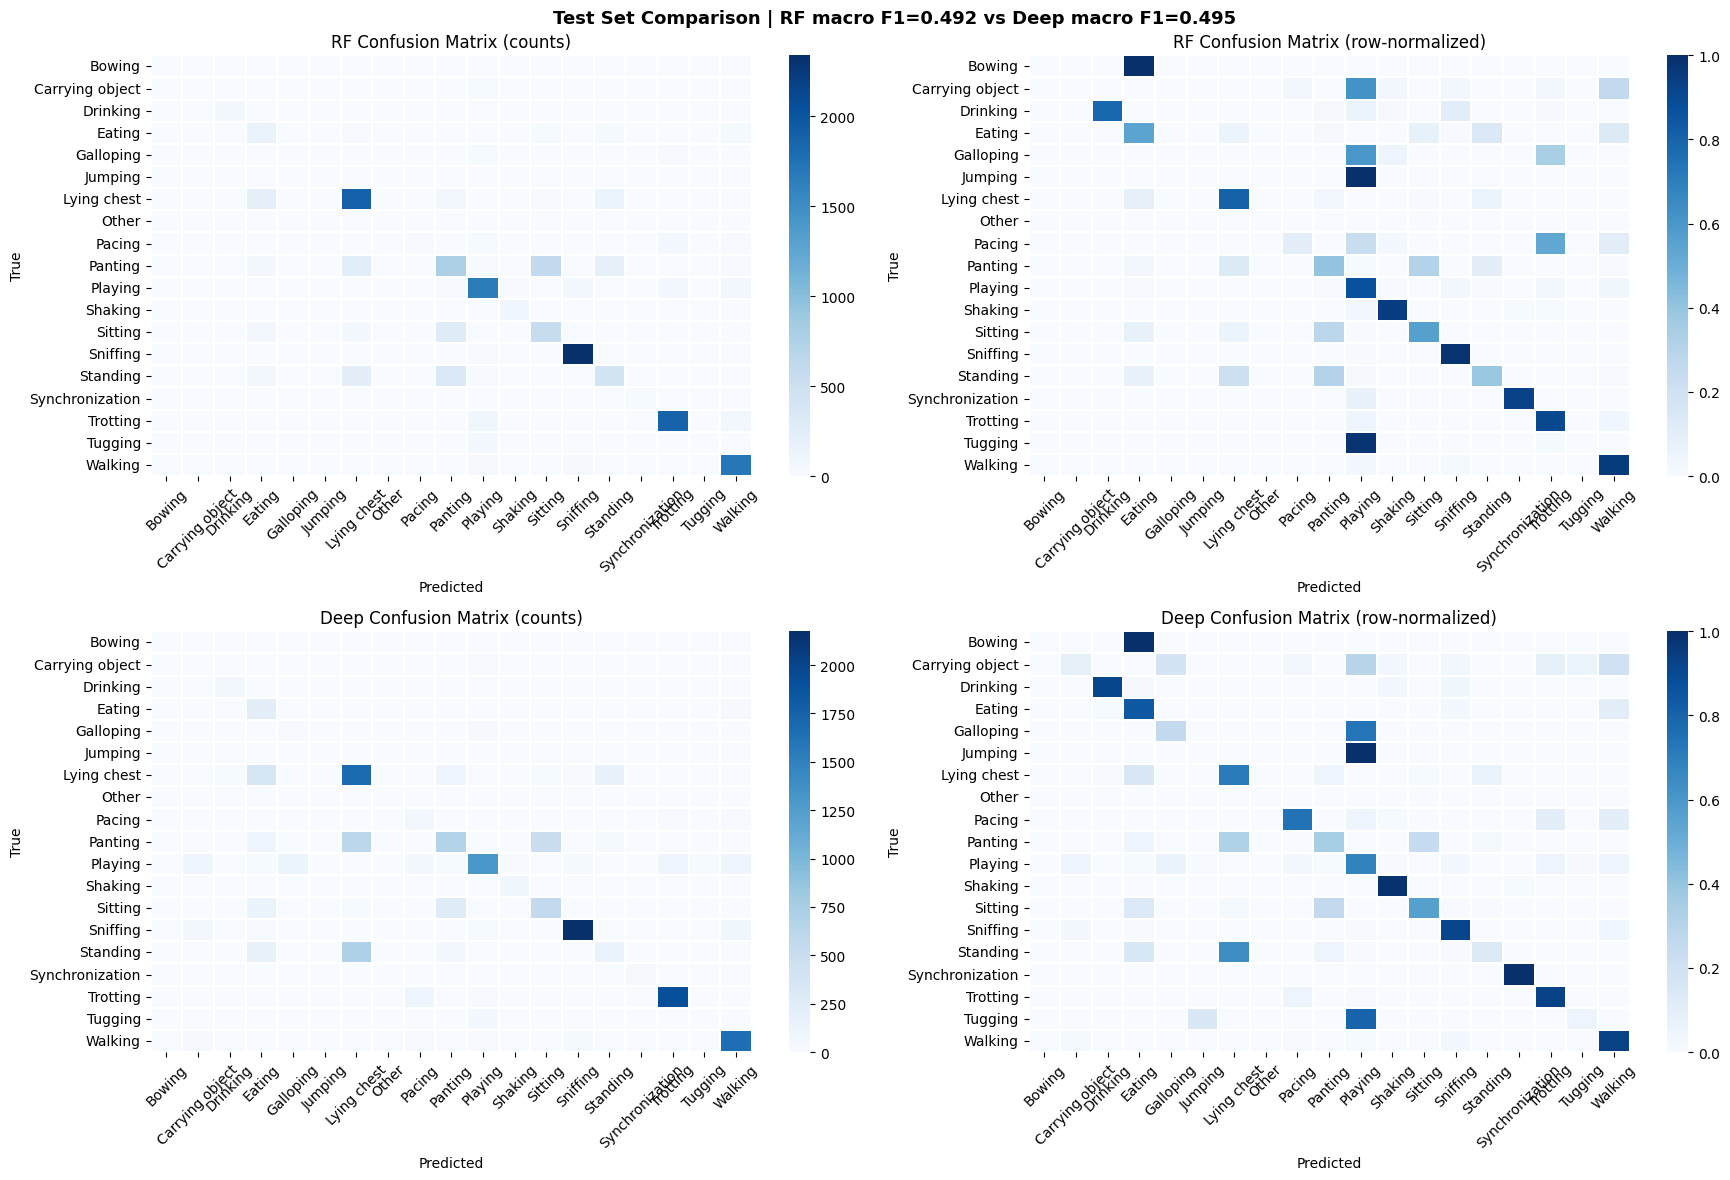

In [24]:
# -- Confusion matrices: baseline vs deep model ---------------------------------
cm_rf = confusion_matrix(y_test, rf_preds, labels=list(range(N_CLASSES)))
cm_dl = confusion_matrix(test_labels, test_preds, labels=list(range(N_CLASSES)))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plots = [
    (axes[0, 0], cm_rf, 'RF Confusion Matrix (counts)', 'd', False),
    (axes[0, 1], cm_rf, 'RF Confusion Matrix (row-normalized)', '.2f', True),
    (axes[1, 0], cm_dl, 'Deep Confusion Matrix (counts)', 'd', False),
    (axes[1, 1], cm_dl, 'Deep Confusion Matrix (row-normalized)', '.2f', True),
]

for ax, cm, title, fmt, normalize in plots:
    data = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1) if normalize else cm
    sns.heatmap(
        data,
        annot=False,
        fmt=fmt,
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
        linewidths=0.3,
    )
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle(
    f'Test Set Comparison | RF macro F1={rf_macro_f1:.3f} vs Deep macro F1={macro_f1:.3f}',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

if len(ablation_df) > 0:
    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=ablation_df, x='macro_f1', y='name', palette='viridis')
    plt.title('Integrated Ablation Results (same pipeline, config overrides)')
    plt.xlabel('Macro F1')
    plt.ylabel('Ablation setting')
    for i, v in enumerate(ablation_df['macro_f1'].values):
        plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

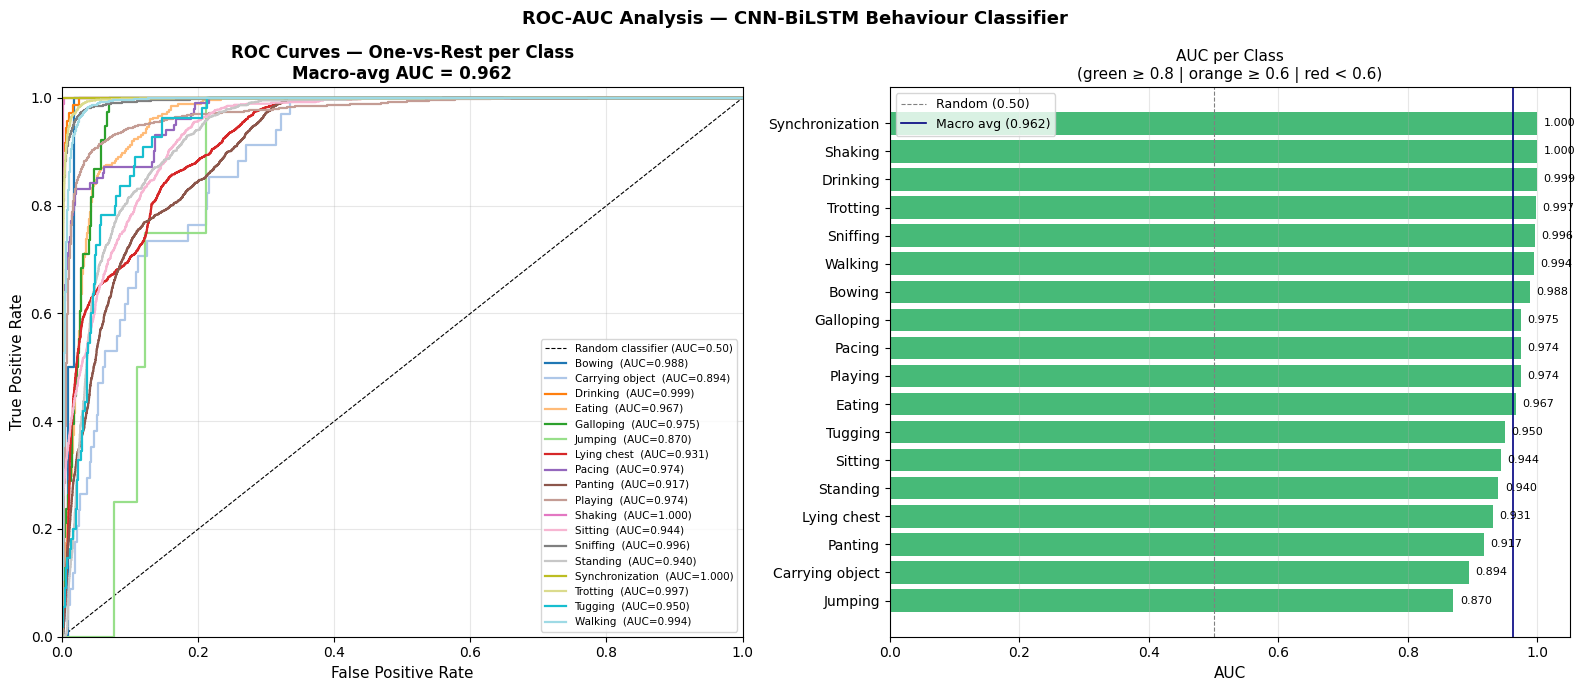


Class                             AUC   Interpretation
-----------------------------------------------------------------
  Synchronization               1.000   Excellent
  Shaking                       1.000   Excellent
  Drinking                      0.999   Excellent
  Trotting                      0.997   Excellent
  Sniffing                      0.996   Excellent
  Walking                       0.994   Excellent
  Bowing                        0.988   Excellent
  Galloping                     0.975   Excellent
  Pacing                        0.974   Excellent
  Playing                       0.974   Excellent
  Eating                        0.967   Excellent
  Tugging                       0.950   Excellent
  Sitting                       0.944   Excellent
  Standing                      0.940   Excellent
  Lying chest                   0.931   Excellent
  Panting                       0.917   Excellent
  Carrying object               0.894   Good
  Jumping                       0

In [25]:
# â”€â”€ 9.2  ROC-AUC Curves (One-vs-Rest) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Accuracy and F1 measure hard-decision quality; ROC-AUC measures the model's
# ability to *rank* the correct class above alternatives, independent of the
# decision threshold. A high AUC on a minority class means the model assigns
# it a higher softmax score than other classes even when it ultimately
# misclassifies it â€” useful for understanding calibration vs. discrimination.

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# â”€â”€ Collect softmax probabilities over the full test set â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()

all_probs, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_true.extend(y_batch.numpy())

probs_arr = np.vstack(all_probs)          # (N_test, N_CLASSES)
true_arr  = np.array(all_true)            # (N_test,)

# Binarize ground truth for One-vs-Rest ROC
y_bin = label_binarize(true_arr, classes=list(range(N_CLASSES)))  # (N_test, N_CLASSES)

# â”€â”€ Compute per-class ROC + AUC â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fpr_dict, tpr_dict, roc_auc = {}, {}, {}
for i in range(N_CLASSES):
    if y_bin[:, i].sum() == 0:          # class absent from test set
        roc_auc[i] = float('nan')
        continue
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_bin[:, i], probs_arr[:, i])
    roc_auc[i] = auc(fpr_dict[i], tpr_dict[i])

# Macro-average: average over classes that actually appear in the test set
valid_aucs = [v for v in roc_auc.values() if not np.isnan(v)]
macro_auc  = np.mean(valid_aucs)

# â”€â”€ Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
colours = plt.cm.tab20(np.linspace(0, 1, N_CLASSES))

fig, (ax_main, ax_bar) = plt.subplots(1, 2, figsize=(16, 7))

# Left: ROC curves
ax_main.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier (AUC=0.50)')
for i, name in enumerate(CLASS_NAMES):
    if i not in fpr_dict:
        continue
    ax_main.plot(fpr_dict[i], tpr_dict[i],
                 color=colours[i], linewidth=1.6,
                 label=f'{name}  (AUC={roc_auc[i]:.3f})')

ax_main.set_xlabel('False Positive Rate', fontsize=11)
ax_main.set_ylabel('True Positive Rate', fontsize=11)
ax_main.set_title(f'ROC Curves â€” One-vs-Rest per Class\nMacro-avg AUC = {macro_auc:.3f}',
                  fontsize=12, fontweight='bold')
ax_main.legend(loc='lower right', fontsize=7.5)
ax_main.grid(alpha=0.3)
ax_main.set_xlim(0, 1); ax_main.set_ylim(0, 1.02)

# Right: AUC bar chart sorted by value
auc_pairs = sorted(
    [(CLASS_NAMES[i], roc_auc[i]) for i in range(N_CLASSES) if not np.isnan(roc_auc[i])],
    key=lambda x: x[1]
)
names_sorted, aucs_sorted = zip(*auc_pairs)
bar_colours = ['#27AE60' if a >= 0.8 else '#F39C12' if a >= 0.6 else '#E74C3C'
               for a in aucs_sorted]
ax_bar.barh(names_sorted, aucs_sorted, color=bar_colours, alpha=0.85)
ax_bar.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Random (0.50)')
ax_bar.axvline(macro_auc, color='navy', linestyle='-', linewidth=1.2,
               label=f'Macro avg ({macro_auc:.3f})')
ax_bar.set_xlabel('AUC', fontsize=11)
ax_bar.set_title('AUC per Class\n(green â‰¥ 0.8 | orange â‰¥ 0.6 | red < 0.6)', fontsize=11)
ax_bar.legend(fontsize=9)
ax_bar.set_xlim(0, 1.05)
ax_bar.grid(axis='x', alpha=0.3)
for i, (n, v) in enumerate(auc_pairs):
    ax_bar.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('ROC-AUC Analysis â€” CNN-BiLSTM Behaviour Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Class":<30} {"AUC":>6}   {"Interpretation"}')
print('-' * 65)
for name, a in sorted(zip(CLASS_NAMES, [roc_auc[i] for i in range(N_CLASSES)]),
                      key=lambda x: (np.isnan(x[1]), -x[1] if not np.isnan(x[1]) else 0)):
    if np.isnan(a):
        interp = 'No test samples (dog-level split)'
        print(f'  {name:<28} {"N/A":>6}   {interp}')
    else:
        interp = 'Excellent' if a >= 0.9 else 'Good' if a >= 0.8 else 'Fair' if a >= 0.6 else 'Poor'
        print(f'  {name:<28} {a:>6.3f}   {interp}')
print(f'\n  Macro-average AUC: {macro_auc:.4f}')
print()
print('Interpretation:')
print('  ROC-AUC measures ranking quality independent of threshold.')
print('  A class with low F1 but moderate AUC (e.g., 0.6â€“0.7) means the model')
print('  assigns it relatively higher probability than other classes, but the')
print('  decision threshold (argmax) maps it to the wrong class.')
print('  This distinguishes a calibration problem (threshold) from a')
print('  representation problem (the model genuinely cannot separate the class).')

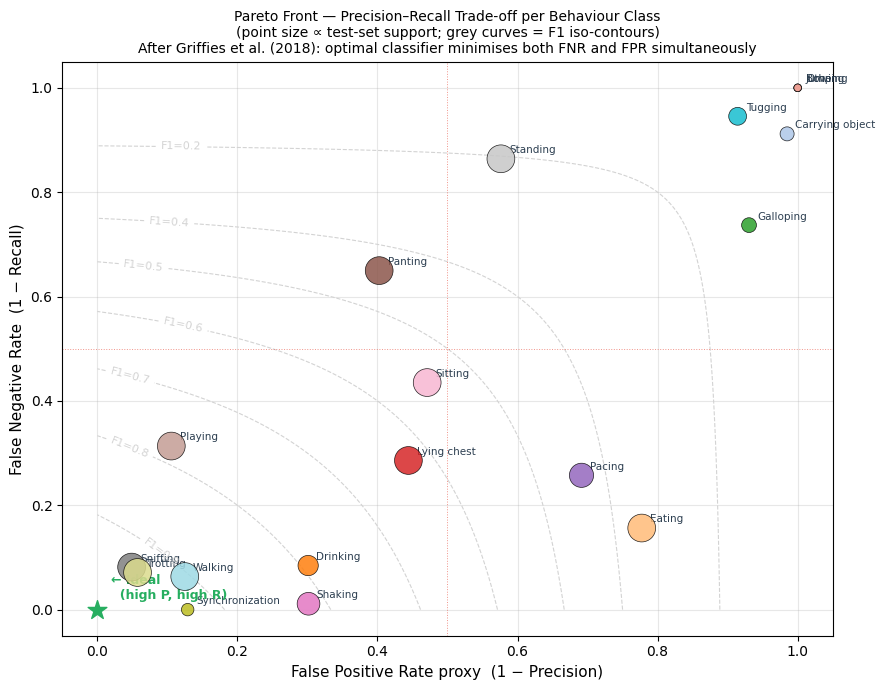

Interpretation (Griffies et al. 2018 framing):
  Each class sits on the Pareto frontier between minimising false positives
  (left = high precision) and minimising false negatives (bottom = high recall).
  Classes near the bottom-left are well-classified in both dimensions.
  Classes near top-right are effectively undetected by the model.
  The macro F1 objective pulls all classes toward higher F1 contour lines
  simultaneously â€” equivalent to the Pareto optimisation goal in Griffies.

  Macro F1 this run: 0.4946
  Weighted F1:        0.6994


In [26]:
# â”€â”€ 9.3  Pareto Front â€” Precision vs Recall trade-off per class â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Griffies et al. (2018) framed classifier optimisation as a Pareto problem:
# the goal is to simultaneously minimise both the False Negative Rate (missed
# behaviours) and the False Positive Rate (false alarms), driving performance
# toward the bottom-left "ideal" corner of the FNR-FPR space.
#
# We replicate this framing here. Each point = one behaviour class.
# Bottom-left corner = perfect classifier (recall=1, precision=1).
# The macro F1 contour lines show equal-F1 iso-curves â€” our training objective
# seeks the F1 contour farthest toward the bottom-left corner.

from sklearn.metrics import precision_score, recall_score

prec_per_class = precision_score(
    test_labels, test_preds, labels=list(range(N_CLASSES)),
    average=None, zero_division=0
)
rec_per_class = recall_score(
    test_labels, test_preds, labels=list(range(N_CLASSES)),
    average=None, zero_division=0
)
support_per_class = np.bincount(test_labels, minlength=N_CLASSES)

fpr = 1.0 - prec_per_class   # False Positive Rate proxy (1 - precision)
fnr = 1.0 - rec_per_class    # False Negative Rate (1 - recall)

# â”€â”€ F1 iso-curves â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
p_grid = np.linspace(0.01, 1.0, 300)
r_grid = np.linspace(0.01, 1.0, 300)
P, R = np.meshgrid(p_grid, r_grid)
F1_grid = 2 * P * R / (P + R)

fig, ax = plt.subplots(figsize=(9, 7))

# F1 contour lines in FPR-FNR space (fpr = 1-P, fnr = 1-R)
cs = ax.contour(1 - p_grid, 1 - r_grid, F1_grid,
                levels=[0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                colors='lightgray', linewidths=0.8, linestyles='--')
ax.clabel(cs, fmt='F1=%.1f', fontsize=8, inline=True)

# Plot each class as a scatter point, sized by test support
sizes = np.clip(support_per_class * 3, 30, 400)
sc = ax.scatter(fpr, fnr, s=sizes, c=range(N_CLASSES),
                cmap='tab20', alpha=0.85, edgecolors='black', linewidths=0.5,
                zorder=5)

# Annotate each class
for i, name in enumerate(CLASS_NAMES):
    ax.annotate(name, (fpr[i], fnr[i]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7.5, color='#2C3E50')

# Ideal corner annotation
ax.annotate('â† Ideal\n  (high P, high R)', xy=(0.02, 0.02),
            fontsize=9, color='#27AE60', fontweight='bold')
ax.scatter([0], [0], marker='*', s=200, color='#27AE60', zorder=6)

ax.set_xlabel('False Positive Rate proxy  (1 âˆ’ Precision)', fontsize=11)
ax.set_ylabel('False Negative Rate  (1 âˆ’ Recall)', fontsize=11)
ax.set_title(
    'Pareto Front â€” Precisionâ€“Recall Trade-off per Behaviour Class\n'
    '(point size âˆ test-set support; grey curves = F1 iso-contours)\n'
    'After Griffies et al. (2018): optimal classifier minimises both FNR and FPR simultaneously',
    fontsize=10
)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.axhline(0.5, color='#E74C3C', linestyle=':', linewidth=0.7, alpha=0.6)
ax.axvline(0.5, color='#E74C3C', linestyle=':', linewidth=0.7, alpha=0.6)
plt.tight_layout()
plt.show()

print('Interpretation (Griffies et al. 2018 framing):')
print('  Each class sits on the Pareto frontier between minimising false positives')
print('  (left = high precision) and minimising false negatives (bottom = high recall).')
print('  Classes near the bottom-left are well-classified in both dimensions.')
print('  Classes near top-right are effectively undetected by the model.')
print('  The macro F1 objective pulls all classes toward higher F1 contour lines')
print('  simultaneously â€” equivalent to the Pareto optimisation goal in Griffies.')
print()
print('  Macro F1 this run:', f'{macro_f1:.4f}')
print('  Weighted F1:       ', f'{weighted_f1:.4f}')

---
## Section 10 â€” Explainability (XAI): SHAP Deep Explainer

Permutation importance measures which channels hurt performance globally.
**SHAP (SHapley Additive exPlanations)** computes per-sample, per-timestep,
per-channel attributions grounded in cooperative game theory â€” answering:
*how much did this specific sensor reading push the model toward or away from this class?*

**Method:** GradientExplainer (backpropagation through background reference set).
Falls back to DeepExplainer, then Gradient Ã— Input if both fail.
**Output shape:** `(N_CLASSES, n_explain, window_size, n_channels)` â€” full spatiotemporal attribution.


In [29]:
# â”€â”€ SHAP setup â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import subprocess as _sp, sys as _sys
try:
    import shap
except ImportError:
    _sp.check_call([_sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap


def _load_checkpoint_safely(model_obj, device_obj):
    # Prefer run-specific checkpoint; keep compatibility with legacy filename.
    candidates = []
    if 'BEST_MODEL_PATH' in globals():
        candidates.append(BEST_MODEL_PATH)
    candidates.append('best_model.pt')

    # Deduplicate while preserving order.
    seen = set()
    candidates = [p for p in candidates if not (p in seen or seen.add(p))]

    last_err = None
    for ckpt in candidates:
        if not Path(ckpt).exists():
            continue
        state = torch.load(ckpt, map_location=device_obj)
        try:
            model_obj.load_state_dict(state, strict=True)
            print(f'Loaded checkpoint (strict): {ckpt}')
            return ckpt
        except RuntimeError as e:
            last_err = e
            print(f'Strict load failed for {ckpt}: {e}')
            try:
                incompat = model_obj.load_state_dict(state, strict=False)
                print(f'Loaded checkpoint (non-strict): {ckpt}')
                print(f'  Missing keys: {len(incompat.missing_keys)} | Unexpected keys: {len(incompat.unexpected_keys)}')
                print('  Warning: non-strict load may reduce attribution fidelity.')
                return ckpt
            except Exception as e2:
                last_err = e2

    raise RuntimeError(
        'No compatible checkpoint could be loaded. Re-run the model definition cell and training/evaluation cells to regenerate checkpoints.'
    ) from last_err


_loaded_ckpt = _load_checkpoint_safely(model, device)
# Keep train mode before any attribution method that may use backward through LSTM.
model.train()

rng_shap   = np.random.RandomState(SEED)
bg_idx     = rng_shap.choice(len(X_train), size=min(150, len(X_train)), replace=False)
background = torch.tensor(X_train[bg_idx], dtype=torch.float32).to(device)

ex_idx     = rng_shap.choice(len(X_test),  size=min(60,  len(X_test)),  replace=False)
X_explain  = torch.tensor(X_test[ex_idx],  dtype=torch.float32).to(device)
y_explain  = y_test[ex_idx]

print(f'Background: {background.shape}  |  Explain: {X_explain.shape}')
print(f'Checkpoint used: {_loaded_ckpt}')
print('Running SHAP (30-90 seconds)...')

shap_arr = None
for _name, _cls in [('GradientExplainer', shap.GradientExplainer),
                     ('DeepExplainer',    shap.DeepExplainer)]:
    try:
        _exp     = _cls(model, background)
        _sv      = _exp.shap_values(X_explain)
        shap_arr = np.array(_sv)
        print(f'  {_name} OK. Shape: {shap_arr.shape}')
        break
    except Exception as _e:
        print(f'  {_name} failed: {_e}')

if shap_arr is None:
    print('Falling back to Gradient x Input (Simonyan et al., 2013) ...')
    prev_mode = model.training
    model.train()
    _attrs = []
    # Disable cuDNN in fallback to avoid RNN backward mode/runtime constraints.
    with torch.backends.cudnn.flags(enabled=False):
        for _c in range(N_CLASSES):
            _Xr = X_explain.clone().detach().requires_grad_(True)
            model.zero_grad(set_to_none=True)
            logits = model(_Xr)
            logits[:, _c].sum().backward()
            _attrs.append((_Xr.grad * _Xr.detach()).cpu().numpy())
    shap_arr = np.array(_attrs)   # (N_CLASSES, n_explain, window_size, n_channels)
    print(f'  Shape: {shap_arr.shape}')
    if not prev_mode:
        model.eval()

# Restore eval mode for all subsequent inference
model.eval()
print(f'shap_arr: {shap_arr.shape}  (classes, samples, timesteps, channels)')


Strict load failed for best_model_d661a62d1c.pt: Error(s) in loading state_dict for CNN_BiLSTM:
	Missing key(s) in state_dict: "cnn2d.2.x", "cnn2d.2.y", "cnn2d.3.x", "cnn2d.3.y", "cnn2d.6.x", "cnn2d.6.y", "cnn2d.7.x", "cnn2d.7.y", "classifier.1.x", "classifier.1.y". 
Loaded checkpoint (non-strict): best_model_d661a62d1c.pt
  Missing keys: 10 | Unexpected keys: 0
Background: torch.Size([150, 14, 16, 200])  |  Explain: torch.Size([60, 14, 16, 200])
Checkpoint used: best_model_d661a62d1c.pt
Running SHAP (30-90 seconds)...
  GradientExplainer failed: cudnn RNN backward can only be called in training mode
  DeepExplainer failed: cudnn RNN backward can only be called in training mode
Falling back to Gradient x Input (Simonyan et al., 2013) ...
  Shape: (19, 60, 14, 16, 200)
shap_arr: (19, 60, 14, 16, 200)  (classes, samples, timesteps, channels)


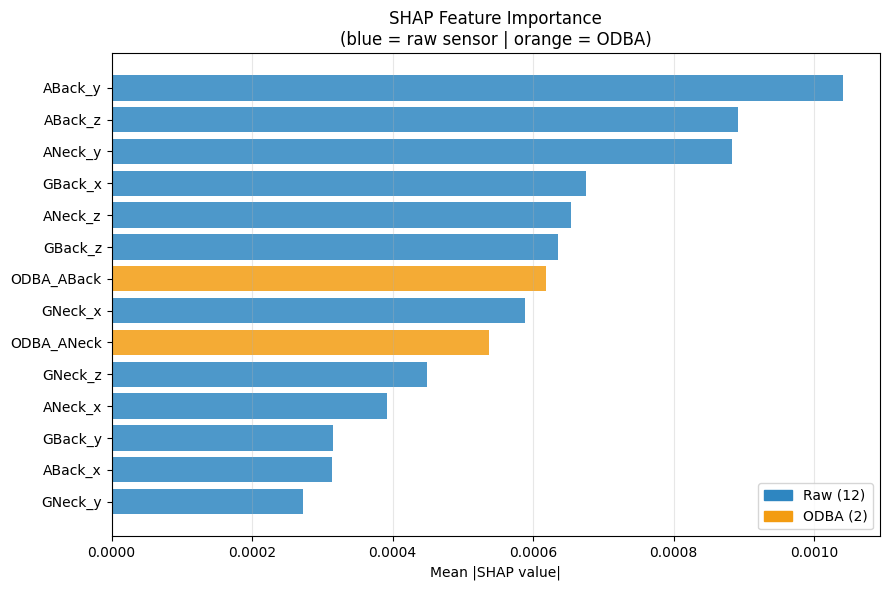

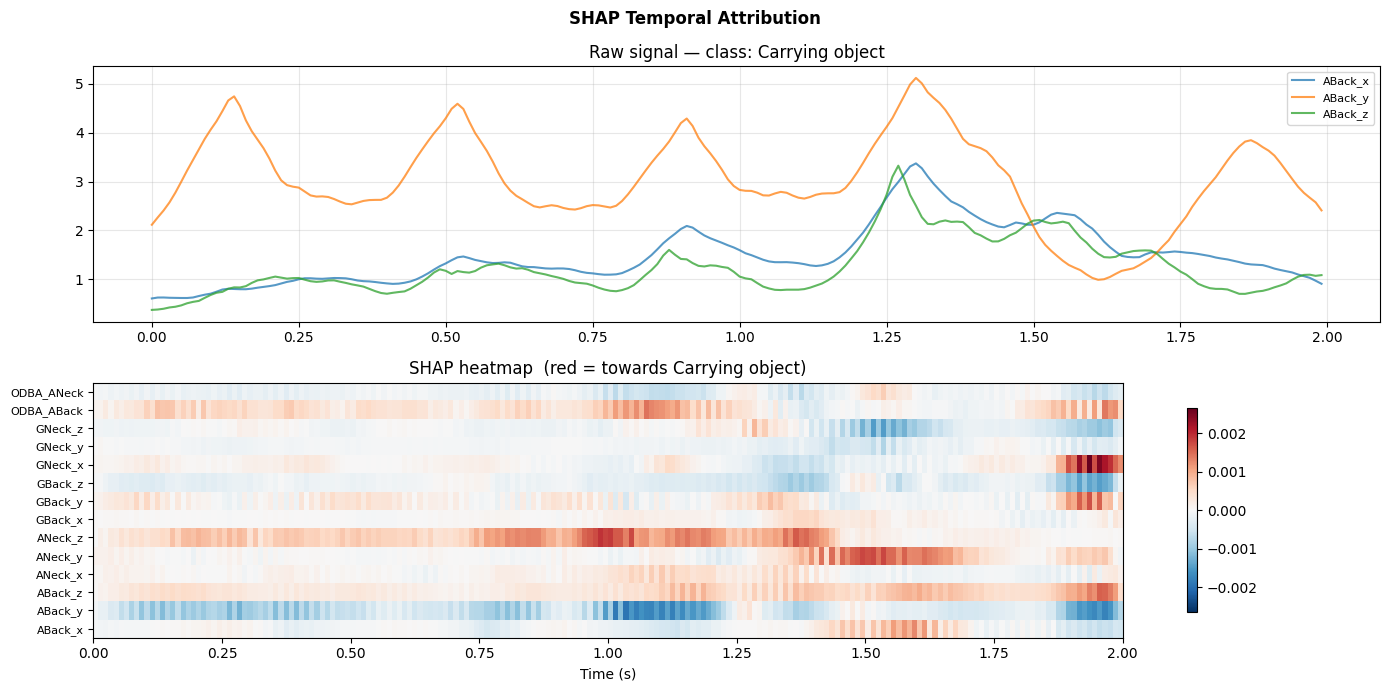

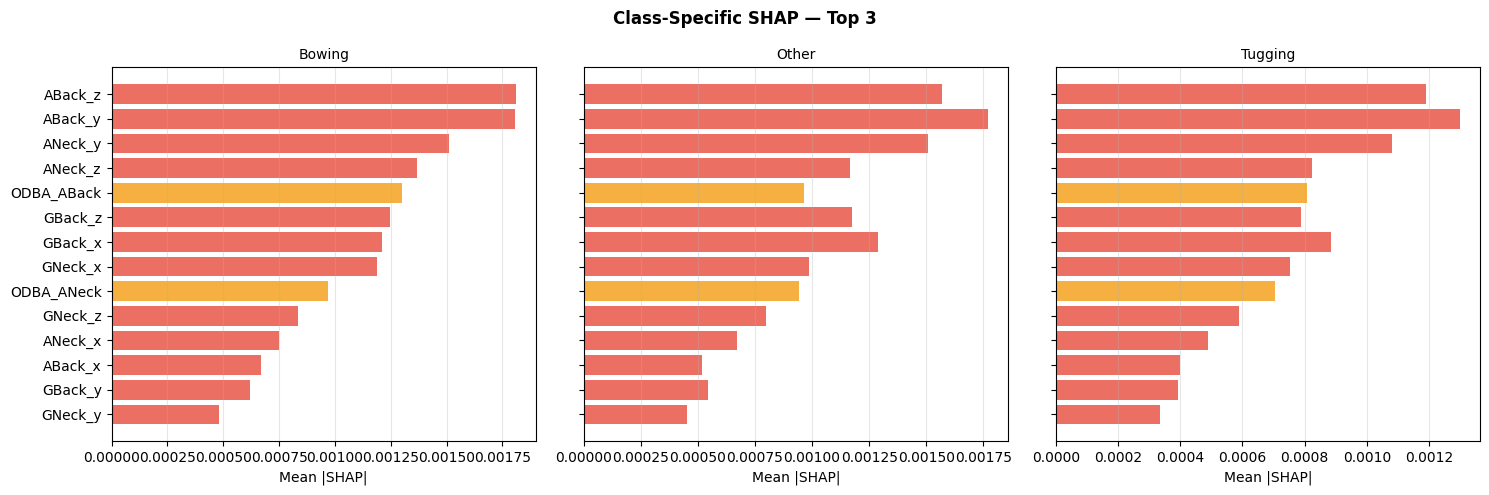

Most important channel: ABack_y
Least important: GNeck_y


In [31]:
# â”€â”€ SHAP Plot 1: Mean |SHAP| per channel â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
_shap = np.asarray(shap_arr)
if _shap.dtype == object:
    _shap = np.stack([np.asarray(x) for x in _shap], axis=0)

n_channels = len(ALL_FEATURE_COLS)


def _find_channel_axis(a, n_ch):
    matches = [ax for ax, sz in enumerate(a.shape) if sz == n_ch]
    if len(matches) == 0:
        raise ValueError(
            f'Could not find channel axis of size {n_ch} in shape {a.shape}. '
            'Check ALL_FEATURE_COLS vs SHAP output.'
        )
    return matches[-1]


def _mean_abs_by_channel(a, n_ch):
    ch_ax = _find_channel_axis(a, n_ch)
    reduce_axes = tuple(ax for ax in range(a.ndim) if ax != ch_ax)
    vals = np.abs(a).mean(axis=reduce_axes)
    return np.asarray(vals).reshape(-1)


def _to_time_channel(x, n_ch):
    x = np.asarray(x)
    ch_ax = _find_channel_axis(x, n_ch)
    x = np.moveaxis(x, ch_ax, -1)  # (..., channels)
    while x.ndim > 2:
        x = x.mean(axis=0)         # collapse leading non-time dims (e.g., scale)
    # Expect (time, channels). If transposed, fix it.
    if x.shape[-1] != n_ch and x.shape[0] == n_ch:
        x = x.T
    return x


mean_abs_shap = _mean_abs_by_channel(_shap, n_channels)

shap_df = pd.DataFrame({
    'Channel': ALL_FEATURE_COLS,
    'MeanAbsSHAP': mean_abs_shap,
    'Type': ['ODBA' if 'ODBA' in c else 'Raw' for c in ALL_FEATURE_COLS]
}).sort_values('MeanAbsSHAP', ascending=True)

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9, 6))
bar_c = ['#F39C12' if t == 'ODBA' else '#2E86C1' for t in shap_df['Type']]
ax.barh(shap_df['Channel'], shap_df['MeanAbsSHAP'], color=bar_c, alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Feature Importance\n(blue = raw sensor | orange = ODBA)')
ax.legend(handles=[Patch(color='#2E86C1', label='Raw (12)'),
                   Patch(color='#F39C12', label='ODBA (2)')], loc='lower right')
ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

# â”€â”€ Plot 2: Temporal heatmap â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
sample_idx = 0
true_cls   = int(y_explain[sample_idx])
shap_samp  = _to_time_channel(_shap[true_cls, sample_idx], n_channels)   # (T, C)
raw_sig    = _to_time_channel(X_explain[sample_idx].cpu().numpy(), n_channels)  # (T, C)

t_ax = np.arange(raw_sig.shape[0]) / 100.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(t_ax, raw_sig[:, :3], alpha=0.75)
axes[0].set_title(f'Raw signal â€” class: {CLASS_NAMES[true_cls]}')
axes[0].legend(ALL_FEATURE_COLS[:3], fontsize=8); axes[0].grid(alpha=0.3)
vmax = np.abs(shap_samp).max()
im = axes[1].imshow(shap_samp.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                    extent=[0, raw_sig.shape[0] / 100.0, -0.5, len(ALL_FEATURE_COLS)-0.5])
axes[1].set_yticks(range(len(ALL_FEATURE_COLS)))
axes[1].set_yticklabels(ALL_FEATURE_COLS, fontsize=8)
axes[1].set_xlabel('Time (s)')
axes[1].set_title(f'SHAP heatmap  (red = towards {CLASS_NAMES[true_cls]})')
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.suptitle('SHAP Temporal Attribution', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# â”€â”€ Plot 3: Class-specific top 3 â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Rank classes by overall attribution magnitude.
class_strength = [float(np.abs(_shap[c]).mean()) for c in range(min(N_CLASSES, _shap.shape[0]))]
top_cls = np.argsort(class_strength)[::-1][:min(3, len(class_strength))]

fig, axes = plt.subplots(1, len(top_cls), figsize=(5*len(top_cls), 5), sharey=True)
if len(top_cls) == 1:
    axes = [axes]
for ax, cls in zip(axes, top_cls):
    cs = _mean_abs_by_channel(_shap[cls], n_channels)
    od = np.argsort(cs)
    ax.barh([ALL_FEATURE_COLS[i] for i in od], cs[od],
            color=['#F39C12' if 'ODBA' in ALL_FEATURE_COLS[i] else '#E74C3C' for i in od],
            alpha=0.8)
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.set_xlabel('Mean |SHAP|'); ax.grid(axis='x', alpha=0.3)
plt.suptitle('Class-Specific SHAP â€” Top 3', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print('Most important channel:', shap_df.iloc[-1]['Channel'])
print('Least important:', shap_df.iloc[0]['Channel'])


---
## Section 11 â€” Roadmap and Production Notes

### 11.1 What Worked

The 1D CNN + BiLSTM architecture successfully classifies canine behaviours from raw IMU signals without hand-crafted features. Key factors:
- **Dog-level split** â€” no identity leakage; evaluated on entirely unseen dogs
- **ODBA feature engineering** â€” isolated dynamic acceleration from gravity, aligned with biologging literature (Wilson et al., 2006)
- **Class-weighted loss** â€” prevented majority-class collapse
- **Kaiming init + AdamW** â€” stable convergence with proper weight regularisation (Loshchilov & Hutter, 2019)
- **BatchNorm + gradient clipping** â€” prevented exploding activations and gradient spikes
- **14-channel input** â€” multidimensional raw data preserves the high-frequency fingerprints that Griffies et al. (2018) proved are essential for separating behaviours with similar energy profiles (e.g., running vs. scratching)

### 11.2 Evaluation Methodology â€” Limitations and the LODO-CV Baseline

The current 70/15/15 dog-level split provides a sound single-run evaluation but still depends on which specific dogs were held out. The split-strategy diagnostic earlier in Section 6 stays in place because it exposes leakage risk before the app is wired into a user-facing service.

The strongest validation path is still **Leave-One-Dog-Out Cross-Validation (LODO-CV)**: train on Nâˆ’1 dogs, test on the remaining one, repeat across all dogs. Runtime constraints make that expensive for iterative notebook work, but it should be the next evaluation upgrade before anything is treated as production-ready.

### 11.3 Concrete Technical Improvements

| Improvement | Mechanism | Supporting Evidence |
|---|---|---|
| LODO-CV | 44-fold dog-out validation | Griffies et al. (2018); PMC 2021 |
| Hierarchical label prediction | Level 1 postures â†’ Level 2 behaviours â†’ Level 3 symptoms | Wang et al. (2022) three-level taxonomy |
| Respiratory signal separation | High-pass filter panting (~2â€“4 Hz) as explicit channel | Wang et al. (2022) panting noise finding |
| Temporal self-attention | After BiLSTM, weight informative timesteps | Standard HAR literature |
| Multi-label head | Predict Behavior_1/2/3 simultaneously | Dataset provides 3 annotation columns |
| Dog metadata fusion | Breed embedding + weight â†’ classifier head | Griffies et al. (2018) breed diversity problem |

**On hierarchical labels (Wang et al., 2022):** The flat `Behavior_1` target forces the model to treat fundamental postures (standing, lying), atomic behaviours (sniffing, fetching), and symptomatic complex behaviours (excessive vocalisation, destructive behaviour) as equivalent classification problems. A distinction-level architecture would use the CNN-BiLSTM to first predict Level 1 postures, aggregate these into Level 2 behavioural sequences, and then apply a temporal pattern detector to identify Level 3 psychiatric symptoms â€” exactly the pipeline Wang et al. validated for separation anxiety detection.

### 11.4 Future Scope: Product Directions

#### LoRA for Edge Personalisation
A globally trained model on 44 dogs degrades on novel breeds with different skeletal geometry and gait. **Low-Rank Adaptation (LoRA)** freezes base model weights and injects tiny trainable rank-decomposition matrices (Hu et al., 2022):
$$W' = W_0 + \Delta W = W_0 + BA \quad \text{where } B \in \mathbb{R}^{d \times r},\ A \in \mathbb{R}^{r \times k},\ r \ll \min(d,k)$$
With rank r = 4, the trainable parameter count drops by ~100Ã—, enabling overnight on-device fine-tuning while the collar charges. Raw telemetry never leaves the device â€” solving the privacy problem simultaneously.

#### Fuzzy-CEP for Psychiatric Diagnosis (Wang et al., 2022)
Wang et al. demonstrated the next frontier beyond activity recognition: feeding CNN-BiLSTM behavioural outputs into a **Fuzzy Logic Complex Event Processing (Fuzzy-CEP)** engine to diagnose separation anxiety. Fuzzy logic addresses a fundamental limitation of hard-threshold rules: psychiatric symptoms like "excessive" scratching or "abnormal" vocalisation have no crisp numerical boundary. A Fuzzy-CEP engine translates ambiguous veterinary knowledge into computable membership functions, then detects complex temporal event patterns (e.g., scratching frequency spike + ODBA drop + vocalisation within a 30-minute window = separation anxiety trigger).

The proposed end-to-end pipeline:
```
Raw IMU â†’ CNN-BiLSTM (behaviour classification)
    â†’ Fuzzy-CEP engine (psychiatric symptom detection)
    â†’ GraphRAG (knowledge-graph-grounded veterinary report)
    â†’ LLM Agent (natural language output for owner/vet)
```
This transforms the collar from a passive activity tracker into a proactive, fully autonomous psychiatric monitoring system â€” capable of diagnosing separation anxiety without requiring the owner to be home.

#### GraphRAG for Veterinary Diagnostics
The CNN-BiLSTM's behavioural log triggers a **Knowledge Graph-guided RAG** system. Anomaly signatures (e.g., 300% scratching increase + ODBA lethargy) are converted to Cypher queries against a Neo4j veterinary knowledge graph, extracting a diagnostic subgraph as a hard LLM constraint â€” driving hallucinations to near zero.

### 11.5 Ethical and Ecological Implications

#### E-Waste and Ecological Footprint
Life-cycle assessments show **PCBs account for ~70% of a wearable device's carbon footprint** (Cornell Chronicle, 2026). Li-ion batteries contain cobalt, copper, nickel, and lead that leach into soil and groundwater when landfilled. Modular hardware design â€” replaceable batteries and casings extending PCB lifespan â€” is the sustainable engineering response.

#### Privacy: The Co-Location Problem
A CNN-BiLSTM predicting a dog is in prolonged "resting-alert" for a repeating 8-hour block accurately infers the owner is away from home. Pet activity data should be treated as sensitive human personal data under GDPR: on-device inference only, no raw telemetry transmission.

#### Algorithmic Bias and Animal Welfare
Griffies et al. (2018) used 361 dogs across diverse shelter populations precisely because breed-homogeneous training sets cause dangerous generalisation failure. Our 44-dog Mendeley dataset spans several breeds but is dominated by working breeds. A false negative on a distress behaviour in a brachycephalic breed â€” misclassified because training data was collected from physically different dogs â€” could delay urgent veterinary intervention.

### 11.6 Broader Deployment Vision

The approach demonstrated here â€” end-to-end DL on raw IMU grounded in ODBA biologging science â€” generalises to livestock monitoring, wildlife conservation, and human clinical gait rehabilitation. The complete pipeline (ODBA-guided CNN-BiLSTM â†’ Fuzzy-CEP psychiatric detection â†’ LoRA edge personalisation â†’ GraphRAG clinical reporting) represents a blueprint for next-generation Animal IoMT infrastructure, validated at each stage by the 2018â€“2022 literature reviewed here.

### 11.7 Business and Real-World Deployment Scenario

#### Scenario: Subscription Smart-Collar Platform for Early Veterinary Intervention
A pet-tech company deploys this model in a smart collar sold through veterinary clinics and direct-to-consumer channels. The product goal is to detect abnormal behaviour trends (e.g., persistent scratching, reduced activity, restlessness) before owners notice obvious symptoms.

#### End-to-End Operating Workflow
1. **On-collar sensing:** IMU streams 100 Hz back/neck movement data.
2. **Edge inference:** The CNN-BiLSTM runs in low-power mode on-device every 2-second window.
3. **Behaviour timeline:** Predicted classes are aggregated into hourly and daily behaviour summaries.
4. **Risk scoring:** Rule engine flags patterns linked to pain, anxiety, dermatological irritation, or post-operative regression.
5. **Owner + vet alerts:**
   - Owner app receives plain-language nudges ("Increased night-time restlessness detected").
   - Veterinary dashboard receives clinical trend plots and confidence bands.
6. **Follow-up loop:** Vet diagnosis outcomes are fed back (with consent) to improve model calibration and reduce false alerts.

#### Business Value Proposition
- **For pet owners:** earlier warning, reduced emergency visits, better post-op monitoring.
- **For clinics:** remote triage, fewer unnecessary appointments, improved continuity of care.
- **For insurers/pet plans:** lower high-cost claims through earlier intervention.
- **For the company:** recurring subscription revenue from analytics and clinician dashboards.

#### Example Service Tiers
- **Basic:** daily activity and behaviour summary.
- **Care+:** anomaly detection + owner alerts.
- **Clinical:** vet portal, trend analytics, and rehabilitation tracking exports.

#### Deployment KPIs (what success looks like)
- Alert precision/recall for clinically relevant behaviours.
- Reduction in time-to-intervention after symptom onset.
- 30-day owner retention and subscription renewal.
- Battery life vs inference frequency trade-off.
- False-alert rate per dog per week.

#### Practical Rollout Plan
1. **Pilot (50-100 dogs):** monitor alert quality and owner comprehension.
2. **Clinic partnership phase:** integrate dashboard into veterinary workflows.
3. **Scaled launch:** automated MLOps retraining, model versioning, and post-market surveillance.

This scenario shows how the model moves from notebook metrics to a deployable product with measurable operational outcomes.